#**BAB I. DATA FOUNDATION**

A.   Colab Setup & Environment

B.   Multi-source Data Acquisition

C.   Hierarchical Integration

D.   Data Dictionary & Varia




**Impor TensorFlow**


Kode ini mengimpor pustaka TensorFlow dan memeriksa apakah GPU tersedia untuk digunakan dalam komputasi. Jika tersedia, daftar perangkat GPU akan ditampilkan; jika tidak, hasilnya akan berupa daftar kosong.

In [2]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


**Mount Googke Drive**

Kode ini mengimpor modul **drive** dari pustaka **google.colab** dan memasangnya (*mount*) ke direktori **`/content/drive`**. Hal ini memungkinkan pengguna Google Colab untuk mengakses file yang tersimpan di Google Drive mereka langsung dari lingkungan Colab.

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

Mounted at /content/drive


#**BAB II. DATA QUALITY & PREPROCESSING**

##**II.A Stratified Data Split**

*   Code Cell: Train/Validation/Test
*   Output Cell: Split summary

**Tahap pembagian data (data splitting)** yang dilakukan sebelum proses pelatihan model. Dataset dibagi menjadi data latih (60%), data validasi (20%), dan data uji (20%) menggunakan metode stratified sampling agar proporsi setiap kelas tetap seimbang pada setiap subset data.

**Output File yang Dihasilkan**

01_data_splits.npz → Menyimpan informasi pembagian data train, validation, dan test.

01_train_raw.csv → Berisi data latih yang digunakan untuk melatih model.

01_val_raw.csv → Berisi data validasi yang digunakan untuk mengevaluasi dan menyempurnakan model selama proses pelatihan.

01_test_raw.csv → Berisi data uji yang digunakan untuk mengukur performa akhir model.

In [ ]:
# =============================================
# II.A STRATIFIED DATA SPLIT
# =============================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"
INPUT_FILE = PATH + "datasetall.csv"
RANDOM_STATE = 42

# Load dataset
df = pd.read_csv(INPUT_FILE)

# =============================================
# Pisahkan ID/Metadata
# =============================================
ID_COLS = ['kabupaten', 'kecamatan', 'desa']

metadata = df[ID_COLS].copy()

# Fitur prediktor (tanpa ID dan target)
X = df.drop(columns=ID_COLS + ['Partisipasi'])

# Target
y = df['Partisipasi']

# =============================================
# Stratified split 60:20:20
# =============================================
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# =============================================
# Simpan metadata sesuai split
# =============================================
meta_train = metadata.loc[X_train.index]
meta_val = metadata.loc[X_val.index]
meta_test = metadata.loc[X_test.index]

# =============================================
# Simpan indeks split
# =============================================
np.savez(
    PATH + '01_data_splits.npz',
    train_idx=X_train.index,
    val_idx=X_val.index,
    test_idx=X_test.index
)

# =============================================
# Simpan dataset fitur + target
# =============================================
pd.concat([X_train, y_train], axis=1).to_csv(
    PATH + '01_train_raw.csv',
    index=False
)

pd.concat([X_val, y_val], axis=1).to_csv(
    PATH + '01_val_raw.csv',
    index=False
)

pd.concat([X_test, y_test], axis=1).to_csv(
    PATH + '01_test_raw.csv',
    index=False
)

# =============================================
# Simpan metadata terpisah
# =============================================
meta_train.to_csv(PATH + '01_train_metadata.csv', index=False)
meta_val.to_csv(PATH + '01_val_metadata.csv', index=False)
meta_test.to_csv(PATH + '01_test_metadata.csv', index=False)

# =============================================
# Output summary
# =============================================
print("="*50)
print("SPLIT SUMMARY")
print("="*50)
print(f"Total samples: {len(df)}")
print(f"Features used for modeling: {X.shape[1]}")
print(f"Metadata columns removed: {len(ID_COLS)}")
print(f"Train: {X_train.shape[0]} (minority {sum(y_train==0)})")
print(f"Val:   {X_val.shape[0]}   (minority {sum(y_val==0)})")
print(f"Test:  {X_test.shape[0]}  (minority {sum(y_test==0)})")
print(f"Imbalance ratio: {sum(y==1)/sum(y==0):.2f}:1")
print("Test set LOCKED until final evaluation.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SPLIT SUMMARY
Total samples: 7021
Features used for modeling: 71
Metadata columns removed: 3
Train: 4212 (minority 859)
Val:   1404   (minority 287)
Test:  1405  (minority 287)
Imbalance ratio: 3.90:1
Test set LOCKED until final evaluation.


##**II.B EDA (Train Only)**


*   Code Cell: Missing, distribution, cardinality
*   Output Cell: EDA report

**Tahap eksplorasi data (Exploratory Data Analysis/EDA)** yang dilakukan pada data latih untuk memahami karakteristik dataset sebelum proses preprocessing dan pelatihan model. Analisis yang dilakukan meliputi pemeriksaan missing value, identifikasi tipe fitur, analisis cardinality pada variabel kategorikal, serta pemeriksaan distribusi kelas target.

**Output File yang Dihasilkan**

02_eda_report.json → Berisi ringkasan hasil EDA, seperti jumlah data, jumlah fitur kategorikal dan numerik, jumlah kolom yang memiliki missing value, jumlah fitur dengan cardinality tinggi, serta rasio ketidakseimbangan kelas.

**Output yang Ditampilkan**
Informasi missing value pada setiap fitur.
Jumlah fitur kategorikal dan fitur numerik.
Daftar fitur dengan high cardinality (jumlah kategori > 10).
Grafik distribusi kelas pada data latih.
Pesan "EDA report saved." sebagai konfirmasi bahwa laporan EDA berhasil disimpan.


Missing values:
 None

Categorical: 4 | Numerical: 67

High-cardinality (>10): 2
  D11: 12 unique
  D17: 113 unique


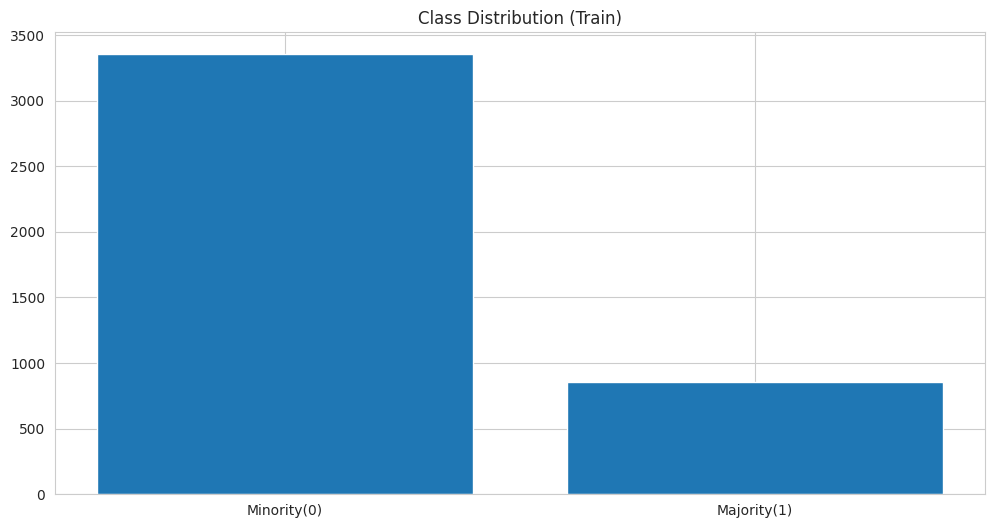


EDA report saved.


In [ ]:
# =============================================
# II.B EDA (TRAIN ONLY)
# =============================================
# Gunakan X_train, y_train dari split sebelumnya

# 1. Missing values
missing = X_train.isnull().sum()
missing_pct = 100 * missing / len(X_train)
print("Missing values:\n", missing[missing>0] if any(missing>0) else "None")

# 2. Feature types
cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(include=[np.number]).columns
print(f"\nCategorical: {len(cat_cols)} | Numerical: {len(num_cols)}")

# 3. Cardinality
card = {col: X_train[col].nunique() for col in cat_cols}
high_card = {k:v for k,v in card.items() if v > 10}
print(f"\nHigh-cardinality (>10): {len(high_card)}")
for k,v in list(high_card.items())[:3]:
    print(f"  {k}: {v} unique")

# 4. Class distribution
import matplotlib.pyplot as plt
class_counts = y_train.value_counts()
plt.bar(['Minority(0)','Majority(1)'], class_counts)
plt.title('Class Distribution (Train)')
plt.show()

# Simpan laporan ringkas
eda_report = {
    'total_samples': len(X_train),
    'missing_cols': len(missing[missing>0]),
    'categorical': len(cat_cols),
    'numerical': len(num_cols),
    'high_cardinality_count': len(high_card),
    'imbalance_ratio': class_counts[1]/class_counts[0]
}
import json
with open(PATH + '02_eda_report.json', 'w') as f:
    json.dump(eda_report, f, indent=2)
print("\nEDA report saved.")

##**II.C Missing Value Handling**


*   Code Cell: Median/Mode Imputation
*   Output Cell: Quality report

**Tahap penanganan missing value (imputation)** untuk mengisi nilai yang hilang pada dataset. Nilai yang hilang pada fitur numerik diisi menggunakan median, sedangkan nilai yang hilang pada fitur kategorikal diisi menggunakan modus (mode). Nilai median dan modus dihitung hanya dari data latih, kemudian diterapkan pada data validasi dan data uji untuk menjaga konsistensi dan menghindari data leakage.

**Output File yang Dihasilkan**

02_train_imputed.csv → Data latih setelah proses imputasi missing value.

02_val_imputed.csv → Data validasi setelah proses imputasi missing value.

02_test_imputed.csv → Data uji setelah proses imputasi missing value.


In [ ]:
# =============================================
# II.C MISSING VALUE HANDLING (Imputation)
# =============================================
# Gunakan X_train, X_val, X_test (raw)
# Buat salinan agar tidak mengubah asli
X_train_imp = X_train.copy()
X_val_imp = X_val.copy()
X_test_imp = X_test.copy()

missing_before = X_train_imp.isnull().sum().sum()
print(f"Missing before imputation: {missing_before} cells")

for col in X_train_imp.columns:
    if X_train_imp[col].isnull().any():
        if X_train_imp[col].dtype in ['float64','int64']:
            med = X_train_imp[col].median()
            X_train_imp[col].fillna(med, inplace=True)
            X_val_imp[col].fillna(med, inplace=True)
            X_test_imp[col].fillna(med, inplace=True)
        else:
            mode = X_train_imp[col].mode()[0]
            X_train_imp[col].fillna(mode, inplace=True)
            X_val_imp[col].fillna(mode, inplace=True)
            X_test_imp[col].fillna(mode, inplace=True)

missing_after = X_train_imp.isnull().sum().sum()
print(f"Missing after imputation: {missing_after}")

# Quality report
print("\nQUALITY REPORT")
print(f"- Total features: {X_train_imp.shape[1]}")
print(f"- Remaining missing: {missing_after}")
print(f"- Imputation method: Median (numeric), Mode (categorical)")
print("- No data leakage (fit only on train)")

# Simpan dataset hasil imputasi
X_train_imp.to_csv(PATH + '02_train_imputed.csv', index=False)
X_val_imp.to_csv(PATH + '02_val_imputed.csv', index=False)
X_test_imp.to_csv(PATH + '02_test_imputed.csv', index=False)
print("Imputed datasets saved.")

Missing before imputation: 0 cells
Missing after imputation: 0

QUALITY REPORT
- Total features: 71
- Remaining missing: 0
- Imputation method: Median (numeric), Mode (categorical)
- No data leakage (fit only on train)
Imputed datasets saved.


##**II.D Hybrid Encoding**


*   Code Cell: OHE + Target Encoding
*   Output Cell: Encoded dataset

**Tahap transformasi data kategorikal (encoding)** untuk mengubah variabel kategorikal menjadi format numerik. Metode yang digunakan adalah Hybrid Encoding, yaitu kombinasi antara One-Hot Encoding (OHE) untuk fitur dengan jumlah kategori sedikit (low-cardinality) dan Target Encoding untuk fitur dengan jumlah kategori banyak (high-cardinality). Pemilihan metode ini bertujuan menghasilkan representasi data yang lebih efisien tanpa menambah dimensi data secara berlebihan.

**Output File yang Dihasilkan**

03_train_encoded.csv → Data latih yang telah diubah ke format numerik menggunakan Hybrid Encoding.

03_val_encoded.csv → Data validasi yang telah diubah ke format numerik menggunakan Hybrid Encoding.

03_test_encoded.csv → Data uji yang telah diubah ke format numerik menggunakan Hybrid Encoding.


In [ ]:
# =============================================
# II.D HYBRID ENCODING (OHE + Target Encoding)
# =============================================
!pip install category-encoders
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder  # pip install category_encoders

# Gunakan X_train_imp, X_val_imp, X_test_imp dari II.C
# Identifikasi categorical features
cat_cols = X_train_imp.select_dtypes(include=['object']).columns.tolist()

# Pisahkan low-cardinality (<10) dan high-cardinality (>=10)
low_card = [c for c in cat_cols if X_train_imp[c].nunique() < 10]
high_card = [c for c in cat_cols if X_train_imp[c].nunique() >= 10]

print(f"Low-cardinality (OHE): {low_card}")
print(f"High-cardinality (Target Encoding): {high_card}")

# One-Hot Encoding untuk low-cardinality
if low_card:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    ohe_train = ohe.fit_transform(X_train_imp[low_card])
    ohe_val = ohe.transform(X_val_imp[low_card])
    ohe_test = ohe.transform(X_test_imp[low_card])
    # Konversi ke DataFrame
    ohe_cols = ohe.get_feature_names_out(low_card)
    ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train_imp.index)
    ohe_val_df = pd.DataFrame(ohe_val, columns=ohe_cols, index=X_val_imp.index)
    ohe_test_df = pd.DataFrame(ohe_test, columns=ohe_cols, index=X_test_imp.index)
else:
    ohe_train_df = pd.DataFrame(index=X_train_imp.index)

# Target Encoding untuk high-cardinality
if high_card:
    te = TargetEncoder(cols=high_card, smoothing=10)
    te.fit(X_train_imp[high_card], y_train)
    te_train = te.transform(X_train_imp[high_card])
    te_val = te.transform(X_val_imp[high_card])
    te_test = te.transform(X_test_imp[high_card])
else:
    te_train = pd.DataFrame(index=X_train_imp.index)

# Gabungkan dengan numerical features
num_cols = X_train_imp.select_dtypes(include=[np.number]).columns
X_train_encoded = pd.concat([
    X_train_imp[num_cols],
    ohe_train_df,
    te_train
], axis=1)
X_val_encoded = pd.concat([
    X_val_imp[num_cols],
    ohe_val_df,
    te_val
], axis=1)
X_test_encoded = pd.concat([
    X_test_imp[num_cols],
    ohe_test_df,
    te_test
], axis=1)

print(f"\nEncoded dataset shape: {X_train_encoded.shape}")
X_train_encoded.to_csv(PATH + '03_train_encoded.csv', index=False)
X_val_encoded.to_csv(PATH + '03_val_encoded.csv', index=False)
X_test_encoded.to_csv(PATH + '03_test_encoded.csv', index=False)
print("Encoded datasets saved.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00
Low-cardinality (OHE): ['D55', 'D57']
High-cardinality (Target Encoding): ['D11', 'D17']

Encoded dataset shape: (4212, 85)
Encoded datasets saved.


##**II.E Scaling & Transformation**


*   Code Cell: StandardScaler
*   Output Cell: Scaled dataset

**Tahap normalisasi skala fitur (feature scaling)** menggunakan metode StandardScaler. Metode ini mengubah setiap fitur sehingga memiliki rata-rata (mean) mendekati 0 dan standar deviasi (standard deviation) mendekati 1. Nilai parameter scaling dihitung dari data latih, kemudian diterapkan pada data validasi dan data uji untuk menghindari data leakage.

**Output File**

04_train_scaled.csv → Data latih yang telah melalui proses scaling.

04_val_scaled.csv → Data validasi yang telah melalui proses scaling.

04_test_scaled.csv → Data uji yang telah melalui proses scaling.


In [ ]:
# =============================================
# II.E SCALING & TRANSFORMATION (StandardScaler)
# =============================================
from sklearn.preprocessing import StandardScaler

# Gunakan X_train_encoded, X_val_encoded, X_test_encoded dari II.D
# Pilih hanya fitur numerik (termasuk hasil encoding numerik)
# Semua fitur setelah encoding seharusnya numerik, kita scaling semua
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Kembalikan ke DataFrame dengan nama kolom asli
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns, index=X_train_encoded.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val_encoded.columns, index=X_val_encoded.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns, index=X_test_encoded.index)

print("Scaling completed using StandardScaler")
print(f"Train mean: {X_train_scaled.mean().mean():.2e}, std: {X_train_scaled.std().mean():.2f}")
print(f"Val mean: {X_val_scaled.mean().mean():.2e}, std: {X_val_scaled.std().mean():.2f}")

X_train_scaled.to_csv(PATH + '04_train_scaled.csv', index=False)
X_val_scaled.to_csv(PATH + '04_val_scaled.csv', index=False)
X_test_scaled.to_csv(PATH + '04_test_scaled.csv', index=False)
print("Scaled datasets saved.")

Scaling completed using StandardScaler
Train mean: -3.47e-17, std: 1.00
Val mean: -1.30e-02, std: 0.96
Scaled datasets saved.


##**II.F Data Consistency Check**


*   Code Cell: Outlier & duplicate check
*   Output Cell: Clean dataset

Kode ini melakukan cek duplicate, cek outlier, lalu menyimpan hasil sebagai clean dataset.

**Output File**

05_train_clean.csv → Data latih yang telah melalui pemeriksaan dan pembersihan data.

05_val_clean.csv → Data validasi yang telah melalui pemeriksaan dan pembersihan data.

05_test_clean.csv → Data uji yang telah melalui pemeriksaan dan pembersihan data.

05_data_consistency_report.json → Laporan ringkasan hasil pemeriksaan duplicate dan outlier.


In [ ]:
# =============================================
# II.F DATA CONSISTENCY CHECK
# Outlier & Duplicate Check
# =============================================
import pandas as pd
import numpy as np
import json

# Gabungkan fitur + target
train_df = pd.concat([X_train_scaled.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
val_df   = pd.concat([X_val_scaled.reset_index(drop=True), y_val.reset_index(drop=True)], axis=1)
test_df  = pd.concat([X_test_scaled.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

# =============================================
# 1) Duplicate check
# =============================================
train_dup = train_df.duplicated().sum()
val_dup   = val_df.duplicated().sum()
test_dup  = test_df.duplicated().sum()

print("="*50)
print("DUPLICATE CHECK")
print("="*50)
print(f"Train duplicates: {train_dup}")
print(f"Val duplicates:   {val_dup}")
print(f"Test duplicates:   {test_dup}")

# Hapus duplicate rows
train_df = train_df.drop_duplicates().reset_index(drop=True)
val_df   = val_df.drop_duplicates().reset_index(drop=True)
test_df  = test_df.drop_duplicates().reset_index(drop=True)

# =============================================
# 2) Outlier check (IQR on train only)
#    Gunakan fitur kontinu saja (bukan binary OHE columns)
# =============================================
feature_cols = X_train_scaled.columns.tolist()

# pilih kolom yang uniknya > 2 agar kolom biner tidak dianggap outlier
continuous_cols = [c for c in feature_cols if X_train_scaled[c].nunique() > 2]

outlier_report = {}
lower_bounds = {}
upper_bounds = {}

if len(continuous_cols) > 0:
    Q1 = X_train_scaled[continuous_cols].quantile(0.25)
    Q3 = X_train_scaled[continuous_cols].quantile(0.75)
    IQR = Q3 - Q1

    lower_bounds = Q1 - 1.5 * IQR
    upper_bounds = Q3 + 1.5 * IQR

    def count_outliers(df, cols, lower, upper):
        mask = pd.DataFrame(False, index=df.index, columns=cols)
        for c in cols:
            mask[c] = (df[c] < lower[c]) | (df[c] > upper[c])
        return mask.sum().sum(), mask.any(axis=1).sum()

    train_out_cells, train_out_rows = count_outliers(X_train_scaled, continuous_cols, lower_bounds, upper_bounds)
    val_out_cells, val_out_rows = count_outliers(X_val_scaled, continuous_cols, lower_bounds, upper_bounds)
    test_out_cells, test_out_rows = count_outliers(X_test_scaled, continuous_cols, lower_bounds, upper_bounds)

    print("\n" + "="*50)
    print("OUTLIER CHECK (IQR)")
    print("="*50)
    print(f"Continuous columns checked: {len(continuous_cols)}")
    print(f"Train outlier rows: {train_out_rows}")
    print(f"Val outlier rows:   {val_out_rows}")
    print(f"Test outlier rows:  {test_out_rows}")

    # Clip outliers using train bounds
    X_train_clean = X_train_scaled.copy()
    X_val_clean   = X_val_scaled.copy()
    X_test_clean  = X_test_scaled.copy()

    X_train_clean[continuous_cols] = X_train_clean[continuous_cols].clip(lower=lower_bounds, upper=upper_bounds, axis=1)
    X_val_clean[continuous_cols]   = X_val_clean[continuous_cols].clip(lower=lower_bounds, upper=upper_bounds, axis=1)
    X_test_clean[continuous_cols]  = X_test_clean[continuous_cols].clip(lower=lower_bounds, upper=upper_bounds, axis=1)

else:
    print("\nNo continuous columns found for outlier check.")
    X_train_clean = X_train_scaled.copy()
    X_val_clean   = X_val_scaled.copy()
    X_test_clean  = X_test_scaled.copy()

# =============================================
# 3) Rebuild clean dataset
# =============================================
train_clean = pd.concat([X_train_clean.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
val_clean   = pd.concat([X_val_clean.reset_index(drop=True), y_val.reset_index(drop=True)], axis=1)
test_clean  = pd.concat([X_test_clean.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

# =============================================
# 4) Save clean dataset
# =============================================
train_clean.to_csv(PATH + '05_train_clean.csv', index=False)
val_clean.to_csv(PATH + '05_val_clean.csv', index=False)
test_clean.to_csv(PATH + '05_test_clean.csv', index=False)

# Save report
clean_report = {
    "train_duplicates_removed": int(train_dup),
    "val_duplicates_removed": int(val_dup),
    "test_duplicates_removed": int(test_dup),
    "continuous_columns_checked": len(continuous_cols),
    "train_rows_final": int(train_clean.shape[0]),
    "val_rows_final": int(val_clean.shape[0]),
    "test_rows_final": int(test_clean.shape[0]),
}

with open(PATH + '05_data_consistency_report.json', 'w') as f:
    json.dump(clean_report, f, indent=2)

print("\nCLEAN DATASET SAVED")
print(f"- 05_train_clean.csv ({train_clean.shape[0]} rows)")
print(f"- 05_val_clean.csv ({val_clean.shape[0]} rows)")
print(f"- 05_test_clean.csv ({test_clean.shape[0]} rows)")
print("- 05_data_consistency_report.json")

DUPLICATE CHECK
Train duplicates: 0
Val duplicates:   0
Test duplicates:   0

OUTLIER CHECK (IQR)
Continuous columns checked: 68
Train outlier rows: 3427
Val outlier rows:   1156
Test outlier rows:  1129

CLEAN DATASET SAVED
- 05_train_clean.csv (4212 rows)
- 05_val_clean.csv (1404 rows)
- 05_test_clean.csv (1405 rows)
- 05_data_consistency_report.json


#**BAB III. FEATURE SCREENING & MULTICOLLINEARITY CONTROL**

##**III.A Correlation Screening**

Tahap penyaringan korelasi dilakukan untuk melihat pasangan fitur yang memiliki hubungan sangat kuat. Jika dua fitur terlalu mirip, salah satunya dapat dihapus agar model tidak mengalami multikolinearitas dan tidak membawa informasi yang berulang.

In [ ]:
# =============================================
# III.A CORRELATION SCREENING
# =============================================
import pandas as pd
import numpy as np
import json

TARGET_COL = 'Partisipasi'
CORR_THRESHOLD = 0.85

# Load clean train data
train_clean = pd.read_csv(PATH + '05_train_clean.csv')
X_train_fs = train_clean.drop(columns=[TARGET_COL]).copy()
y_train_fs = train_clean[TARGET_COL].copy()

# Ambil hanya fitur numerik
num_cols = X_train_fs.select_dtypes(include=[np.number]).columns.tolist()

# Korelasi antar fitur
corr_matrix = X_train_fs[num_cols].corr().abs()

# Ambil pasangan fitur yang korelasinya tinggi
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        if pd.notna(val) and val >= CORR_THRESHOLD:
            high_corr_pairs.append((row, col, float(val)))

corr_pairs_df = pd.DataFrame(high_corr_pairs, columns=['feature_1', 'feature_2', 'abs_corr'])
corr_pairs_df = corr_pairs_df.sort_values('abs_corr', ascending=False)

# Korelasi fitur terhadap target
target_corr = pd.concat([X_train_fs[num_cols], y_train_fs], axis=1).corr()[TARGET_COL].abs().drop(TARGET_COL)

# Tentukan kandidat fitur yang akan dihapus
drop_corr = []
for f1, f2, c in high_corr_pairs:
    c1 = target_corr.get(f1, 0)
    c2 = target_corr.get(f2, 0)
    drop_corr.append(f1 if c1 < c2 else f2)

drop_corr = sorted(set(drop_corr))

# Fitur tersisa setelah screening korelasi
features_after_corr = [c for c in X_train_fs.columns if c not in drop_corr]

# Simpan hasil
corr_pairs_df.to_csv(PATH + '06_corr_high_pairs.csv', index=False)
pd.DataFrame({'feature_to_drop': drop_corr}).to_csv(PATH + '06_corr_drop_candidates.csv', index=False)

with open(PATH + '06_corr_screening_summary.json', 'w') as f:
    json.dump({
        'total_features': len(num_cols),
        'high_corr_pairs_found': len(corr_pairs_df),
        'features_dropped_by_correlation': len(drop_corr),
        'features_remaining': len(features_after_corr),
        'threshold': CORR_THRESHOLD
    }, f, indent=2)

print("="*50)
print("CORRELATION SCREENING")
print("="*50)
print(f"Total numeric features: {len(num_cols)}")
print(f"High-correlation pairs: {len(corr_pairs_df)}")
print(f"Features marked for drop: {len(drop_corr)}")
print(f"Remaining features: {len(features_after_corr)}")
print("Correlation screening saved.")

CORRELATION SCREENING
Total numeric features: 85
High-correlation pairs: 37
Features marked for drop: 16
Remaining features: 69
Correlation screening saved.


##**III.B VIF Analysis**

**Tahap VIF (Variance Inflation Factor)** digunakan untuk mengecek multikolinearitas antar fitur yang masih tersisa setelah screening korelasi. Fitur dengan VIF tinggi menunjukkan hubungan linear yang kuat dengan fitur lain, sehingga dapat mengganggu stabilitas model.


In [ ]:
# =============================================
# III.B VIF ANALYSIS
# =============================================
from statsmodels.stats.outliers_influence import variance_inflation_factor

VIF_THRESHOLD = 10.0

# Dataset kandidat setelah correlation screening
X_vif = X_train_fs[features_after_corr].copy()

# Ambil hanya kolom numerik
X_vif = X_vif.select_dtypes(include=[np.number]).copy()

# Hapus kolom dengan variansi nol
X_vif = X_vif.loc[:, X_vif.nunique(dropna=False) > 1]

def compute_vif(df):
    vif_data = []
    X = df.astype(float).copy()
    for i, col in enumerate(X.columns):
        try:
            vif_val = variance_inflation_factor(X.values, i)
        except Exception:
            vif_val = np.inf
        vif_data.append((col, vif_val))
    return pd.DataFrame(vif_data, columns=['feature', 'VIF']).sort_values('VIF', ascending=False).reset_index(drop=True)

# Iteratif: hapus fitur dengan VIF tertinggi sampai memenuhi ambang batas
remaining_features = list(X_vif.columns)
removed_vif = []

while len(remaining_features) > 1:
    vif_df = compute_vif(X_vif[remaining_features])
    max_vif = vif_df['VIF'].max()

    if np.isfinite(max_vif) and max_vif <= VIF_THRESHOLD:
        break

    worst_feature = vif_df.iloc[0]['feature']
    removed_vif.append(worst_feature)
    remaining_features.remove(worst_feature)

final_vif_df = compute_vif(X_vif[remaining_features])

# Simpan hasil
final_vif_df.to_csv(PATH + '06_vif_final_report.csv', index=False)
pd.DataFrame({'feature_to_drop': removed_vif}).to_csv(PATH + '06_vif_drop_candidates.csv', index=False)

with open(PATH + '06_vif_summary.json', 'w') as f:
    json.dump({
        'vif_threshold': VIF_THRESHOLD,
        'features_checked': len(X_vif.columns),
        'features_dropped_by_vif': len(removed_vif),
        'features_remaining_after_vif': len(remaining_features)
    }, f, indent=2)

print("="*50)
print("VIF ANALYSIS")
print("="*50)
print(f"Features checked: {len(X_vif.columns)}")
print(f"Features dropped by VIF: {len(removed_vif)}")
print(f"Remaining features: {len(remaining_features)}")
print("VIF analysis saved.")

VIF ANALYSIS
Features checked: 65
Features dropped by VIF: 10
Remaining features: 55
VIF analysis saved.


##**III.C Feature Reduction**

Tahap reduksi fitur dilakukan untuk menyimpan hanya fitur yang lolos screening korelasi dan VIF. Hasilnya adalah dataset yang lebih ringkas, lebih stabil, dan lebih siap digunakan untuk pemodelan.

In [ ]:
# =============================================
# III.C FEATURE REDUCTION
# =============================================
TARGET_COL = 'Partisipasi'

# Load val dan test clean
val_clean = pd.read_csv(PATH + '05_val_clean.csv')
test_clean = pd.read_csv(PATH + '05_test_clean.csv')

# Fitur final hasil screening + VIF
final_features = remaining_features

# Pastikan fitur ada pada semua subset
train_reduced = train_clean[final_features + [TARGET_COL]].copy()
val_reduced   = val_clean[final_features + [TARGET_COL]].copy()
test_reduced  = test_clean[final_features + [TARGET_COL]].copy()

# Simpan dataset hasil reduksi
train_reduced.to_csv(PATH + '06_train_reduced.csv', index=False)
val_reduced.to_csv(PATH + '06_val_reduced.csv', index=False)
test_reduced.to_csv(PATH + '06_test_reduced.csv', index=False)

# Simpan daftar fitur final
pd.DataFrame({'selected_feature': final_features}).to_csv(PATH + '06_selected_features.csv', index=False)

with open(PATH + '06_feature_reduction_summary.json', 'w') as f:
    json.dump({
        'final_selected_features': len(final_features),
        'train_rows': train_reduced.shape[0],
        'val_rows': val_reduced.shape[0],
        'test_rows': test_reduced.shape[0]
    }, f, indent=2)

print("="*50)
print("FEATURE REDUCTION")
print("="*50)
print(f"Selected features: {len(final_features)}")
print(f"Train shape: {train_reduced.shape}")
print(f"Val shape:   {val_reduced.shape}")
print(f"Test shape:  {test_reduced.shape}")
print("Reduced datasets saved.")

FEATURE REDUCTION
Selected features: 55
Train shape: (4212, 56)
Val shape:   (1404, 56)
Test shape:  (1405, 56)
Reduced datasets saved.


##**III.D Comparative Feature Selection**

In [ ]:
# =============================================
# III.D COMPARATIVE FEATURE SELECTION
# Common Setup
# =============================================
from google.colab import drive
drive.mount('/content/drive')

!pip -q install skrebate

import pandas as pd
import numpy as np
import json

from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from skrebate import ReliefF

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"
TARGET_COL = "Partisipasi"
RANDOM_STATE = 42

# Load data hasil tahap sebelumnya
train_clean = pd.read_csv(PATH + "05_train_clean.csv")
val_clean   = pd.read_csv(PATH + "05_val_clean.csv")
test_clean  = pd.read_csv(PATH + "05_test_clean.csv")

X_train = train_clean.drop(columns=[TARGET_COL]).copy()
y_train = train_clean[TARGET_COL].copy()

X_val = val_clean.drop(columns=[TARGET_COL]).copy()
y_val = val_clean[TARGET_COL].copy()

X_test = test_clean.drop(columns=[TARGET_COL]).copy()
y_test = test_clean[TARGET_COL].copy()

# Pastikan semua fitur numerik
X_train = X_train.select_dtypes(include=[np.number]).copy()
X_val   = X_val[X_train.columns].copy()
X_test  = X_test[X_train.columns].copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
clf = LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear")
EPS = 1e-9

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Preparing metadata (setup.py) ... done


###**III.D.1 Method 1 (MI+ReliefF+GWO) → Highest imbalance robustness**

Tahap ini memilih fitur dengan kombinasi Mutual Information dan ReliefF, lalu mencari subset terbaik menggunakan Grey Wolf Optimizer (GWO). Metode ini cocok untuk data yang tidak seimbang karena evaluasinya memakai balanced accuracy dan class_weight='balanced'

In [ ]:
# =============================================
# III.D.1 METHOD 1: MI + ReliefF + GWO
# Highest imbalance robustness
# =============================================

# 1) Hitung skor MI
mi_scores = pd.Series(
    mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE),
    index=X_train.columns
)

# 2) Hitung skor ReliefF
relief = ReliefF(n_neighbors=10, n_features_to_select=X_train.shape[1])
relief.fit(X_train.values, y_train.values)
relief_scores = pd.Series(relief.feature_importances_, index=X_train.columns)

# 3) Normalisasi dan gabungkan
score_df = pd.DataFrame({
    "mi": mi_scores,
    "relief": relief_scores
})
score_df = (score_df - score_df.min()) / (score_df.max() - score_df.min() + EPS)
score_df["combined"] = 0.5 * score_df["mi"] + 0.5 * score_df["relief"]
score_df = score_df.sort_values("combined", ascending=False)

# Ambil kandidat teratas agar GWO lebih ringan
candidate_k = min(30, len(score_df))
candidate_features = score_df.head(candidate_k).index.tolist()

print("Candidate features for GWO:", candidate_features)

# 4) Fungsi evaluasi subset
def evaluate_subset(mask, X, y, features, cv, model):
    idx = np.where(mask == 1)[0]
    if len(idx) == 0:
        return 1.0  # penalti kalau tidak ada fitur dipilih

    cols = [features[i] for i in idx]
    X_sub = X[cols]
    score = cross_val_score(model, X_sub, y, scoring="balanced_accuracy", cv=cv, n_jobs=-1).mean()

    # penalti ukuran subset agar tidak terlalu banyak fitur
    penalty = 0.01 * (len(cols) / len(features))
    return 1.0 - score + penalty

# 5) Binary GWO sederhana
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binary_gwo(X, y, features, n_wolves=12, n_iter=20, random_state=42):
    rng = np.random.default_rng(random_state)
    dim = len(features)

    # posisi awal berupa probabilitas
    wolves = rng.random((n_wolves, dim))
    best_pos = None
    best_fit = np.inf

    for t in range(n_iter):
        # ubah ke biner
        binary_wolves = (wolves > 0.5).astype(int)

        fitness = np.array([
            evaluate_subset(binary_wolves[i], X, y, features, cv, clf)
            for i in range(n_wolves)
        ])

        order = np.argsort(fitness)
        alpha = binary_wolves[order[0]].copy()
        beta  = binary_wolves[order[1]].copy() if n_wolves > 1 else alpha.copy()
        delta = binary_wolves[order[2]].copy() if n_wolves > 2 else alpha.copy()

        if fitness[order[0]] < best_fit:
            best_fit = fitness[order[0]]
            best_pos = alpha.copy()

        a = 2 - t * (2 / max(n_iter - 1, 1))

        # update posisi
        for i in range(n_wolves):
            for j in range(dim):
                r1, r2 = rng.random(), rng.random()
                A1 = 2 * a * r1 - a
                C1 = 2 * r2
                D_alpha = abs(C1 * alpha[j] - wolves[i, j])
                X1 = alpha[j] - A1 * D_alpha

                r1, r2 = rng.random(), rng.random()
                A2 = 2 * a * r1 - a
                C2 = 2 * r2
                D_beta = abs(C2 * beta[j] - wolves[i, j])
                X2 = beta[j] - A2 * D_beta

                r1, r2 = rng.random(), rng.random()
                A3 = 2 * a * r1 - a
                C3 = 2 * r2
                D_delta = abs(C3 * delta[j] - wolves[i, j])
                X3 = delta[j] - A3 * D_delta

                new_pos = (X1 + X2 + X3) / 3.0
                wolves[i, j] = sigmoid(new_pos)

    return best_pos, best_fit

best_mask, best_fit = binary_gwo(X_train, y_train, candidate_features, n_wolves=12, n_iter=20, random_state=RANDOM_STATE)

selected_features_m1 = [candidate_features[i] for i in np.where(best_mask == 1)[0]]
if len(selected_features_m1) == 0:
    selected_features_m1 = [score_df.index[0]]

print("\nSelected features Method 1:", selected_features_m1)
print("Number of selected features:", len(selected_features_m1))

# 6) Simpan dataset hasil seleksi
train_m1 = train_clean[selected_features_m1 + [TARGET_COL]].copy()
val_m1   = val_clean[selected_features_m1 + [TARGET_COL]].copy()
test_m1  = test_clean[selected_features_m1 + [TARGET_COL]].copy()

train_m1.to_csv(PATH + "07_m1_train_selected.csv", index=False)
val_m1.to_csv(PATH + "07_m1_val_selected.csv", index=False)
test_m1.to_csv(PATH + "07_m1_test_selected.csv", index=False)

pd.DataFrame({"selected_feature": selected_features_m1}).to_csv(
    PATH + "07_m1_selected_features.csv", index=False
)

with open(PATH + "07_m1_summary.json", "w") as f:
    json.dump({
        "method": "MI + ReliefF + GWO",
        "selected_features": selected_features_m1,
        "n_selected": len(selected_features_m1),
        "best_fitness": float(best_fit)
    }, f, indent=2)

print("Method 1 saved.")

Candidate features for GWO: ['P1', 'Proporsi_Netral', 'P9', 'P6', 'P7', 'P10', 'P5', 'P3', 'P4', 'D61', 'D65', 'D64', 'Proporsi_Negatif', 'D4', 'D60', 'P8', 'D50', 'D67', 'D33', 'D26', 'D56', 'D27', 'D22', 'D11', 'D37', 'D44', 'D5', 'D46', 'D53', 'D43']

Selected features Method 1: ['P1', 'Proporsi_Netral', 'P6', 'P7', 'P10', 'P5', 'P3', 'P4', 'D61', 'D64', 'D4', 'D60', 'P8', 'D50', 'D67', 'D33', 'D26', 'D56', 'D27', 'D22', 'D11', 'D37', 'D43']
Number of selected features: 23
Method 1 saved.


###**III.D.2 Method 2 (Spearman+Fisher+SFS) → Best interpretability**

Tahap ini memilih fitur berdasarkan hubungan monotonic dengan target menggunakan Spearman, lalu memperkuat seleksi dengan Fisher score. Setelah itu dipilih subset akhir memakai Sequential Forward Selection (SFS). Metode ini lebih mudah dijelaskan karena proses pemilihannya bertahap dan transparan.

In [ ]:
# =============================================
# III.D.2 METHOD 2: Spearman + Fisher + SFS
# Best interpretability
# =============================================

# 1) Spearman correlation score
spearman_scores = {}
for col in X_train.columns:
    corr, _ = spearmanr(X_train[col], y_train)
    spearman_scores[col] = 0.0 if np.isnan(corr) else abs(corr)
spearman_scores = pd.Series(spearman_scores)

# 2) Fisher score (binary class)
def fisher_score(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y)

    classes = np.unique(y)
    overall_mean = np.mean(x)
    num = 0.0
    den = 0.0

    for c in classes:
        xc = x[y == c]
        nc = len(xc)
        if nc == 0:
            continue
        mu_c = np.mean(xc)
        var_c = np.var(xc)
        num += nc * (mu_c - overall_mean) ** 2
        den += nc * var_c

    return num / (den + EPS)

fisher_scores = pd.Series(
    {col: fisher_score(X_train[col].values, y_train.values) for col in X_train.columns}
)

# 3) Gabungkan skor
score_df2 = pd.DataFrame({
    "spearman": spearman_scores,
    "fisher": fisher_scores
})
score_df2 = (score_df2 - score_df2.min()) / (score_df2.max() - score_df2.min() + EPS)
score_df2["combined"] = 0.5 * score_df2["spearman"] + 0.5 * score_df2["fisher"]
score_df2 = score_df2.sort_values("combined", ascending=False)

# Kandidat awal untuk SFS
candidate_k = min(20, len(score_df2))
candidate_features = score_df2.head(candidate_k).index.tolist()

print("Candidate features for SFS:", candidate_features)

# 4) Sequential Forward Selection sederhana
MAX_FEATURES = min(10, len(candidate_features))
selected_features_m2 = []
remaining = candidate_features.copy()
best_global = -np.inf

for step in range(MAX_FEATURES):
    best_feat = None
    best_step_score = -np.inf

    for feat in remaining:
        trial = selected_features_m2 + [feat]
        score = cross_val_score(
            clf, X_train[trial], y_train,
            scoring="balanced_accuracy",
            cv=cv, n_jobs=-1
        ).mean()

        if score > best_step_score:
            best_step_score = score
            best_feat = feat

    # stop kalau tidak ada peningkatan berarti
    if step > 0 and best_step_score <= best_global + 1e-4:
        break

    selected_features_m2.append(best_feat)
    remaining.remove(best_feat)
    best_global = best_step_score

print("\nSelected features Method 2:", selected_features_m2)
print("Number of selected features:", len(selected_features_m2))

# 5) Simpan dataset hasil seleksi
train_m2 = train_clean[selected_features_m2 + [TARGET_COL]].copy()
val_m2   = val_clean[selected_features_m2 + [TARGET_COL]].copy()
test_m2  = test_clean[selected_features_m2 + [TARGET_COL]].copy()

train_m2.to_csv(PATH + "07_m2_train_selected.csv", index=False)
val_m2.to_csv(PATH + "07_m2_val_selected.csv", index=False)
test_m2.to_csv(PATH + "07_m2_test_selected.csv", index=False)

pd.DataFrame({"selected_feature": selected_features_m2}).to_csv(
    PATH + "07_m2_selected_features.csv", index=False
)

with open(PATH + "07_m2_summary.json", "w") as f:
    json.dump({
        "method": "Spearman + Fisher + SFS",
        "selected_features": selected_features_m2,
        "n_selected": len(selected_features_m2),
        "best_cv_score": float(best_global)
    }, f, indent=2)

print("Method 2 saved.")

Candidate features for SFS: ['P1', 'P5', 'P8', 'P6', 'P7', 'P9', 'P3', 'P4', 'P10', 'D50', 'D51', 'D37', 'D44', 'D29', 'D35', 'D30', 'D25', 'D45', 'D57_7', 'D31']

Selected features Method 2: ['D37', 'P1', 'P4', 'P8', 'P5', 'P7', 'P6']
Number of selected features: 7
Method 2 saved.


###**III.D.3 Method 3 (mRMR+DEA)**

Tahap ini memilih fitur dengan prinsip relevansi tinggi dan redundansi rendah memakai mRMR. Setelah itu dilakukan penyaringan akhir dengan pendekatan DEA untuk mendapatkan fitur yang paling efisien. Di sini saya buat versi praktis berupa DEA-inspired efficiency score agar bisa langsung dijalankan di Colab.

In [ ]:
# =============================================
# III.D.3 METHOD 3: mRMR + DEA
# Practical DEA-inspired feature ranking
# =============================================

# 1) Mutual information sebagai relevansi
mi_scores = pd.Series(
    mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE),
    index=X_train.columns
)

# 2) Matriks korelasi absolut sebagai redundansi
corr_abs = X_train.corr().abs().fillna(0)

# 3) mRMR greedy ranking
remaining = mi_scores.sort_values(ascending=False).index.tolist()
selected_mrmr = []

if remaining:
    selected_mrmr.append(remaining.pop(0))

while remaining:
    best_feat = None
    best_score = -np.inf

    for feat in remaining:
        redundancy = np.mean([corr_abs.loc[feat, s] for s in selected_mrmr]) if selected_mrmr else 0.0
        score = mi_scores[feat] - redundancy
        if score > best_score:
            best_score = score
            best_feat = feat

    selected_mrmr.append(best_feat)
    remaining.remove(best_feat)

mrmr_rank = pd.DataFrame({
    "feature": selected_mrmr,
    "mi_score": [mi_scores[f] for f in selected_mrmr]
})

# 4) DEA-inspired efficiency score pada kandidat teratas mRMR
candidate_k = min(25, len(selected_mrmr))
candidate_features = selected_mrmr[:candidate_k]

relevance = pd.Series({f: mi_scores[f] for f in candidate_features})
relevance_norm = (relevance - relevance.min()) / (relevance.max() - relevance.min() + EPS)

redundancy = pd.Series({
    f: np.mean([corr_abs.loc[f, other] for other in candidate_features if other != f]) if len(candidate_features) > 1 else 0.0
    for f in candidate_features
})
redundancy_norm = (redundancy - redundancy.min()) / (redundancy.max() - redundancy.min() + EPS)

dea_efficiency = relevance_norm / (redundancy_norm + EPS)

final_score = pd.DataFrame({
    "relevance": relevance_norm,
    "redundancy": redundancy_norm,
    "dea_efficiency": dea_efficiency
})
final_score["combined"] = 0.5 * final_score["relevance"] + 0.5 * final_score["dea_efficiency"]
final_score = final_score.sort_values("combined", ascending=False)

# Ambil fitur final
N_SELECT = min(10, len(final_score))
selected_features_m3 = final_score.head(N_SELECT).index.tolist()

print("\nSelected features Method 3:", selected_features_m3)
print("Number of selected features:", len(selected_features_m3))

# 5) Simpan dataset hasil seleksi
train_m3 = train_clean[selected_features_m3 + [TARGET_COL]].copy()
val_m3   = val_clean[selected_features_m3 + [TARGET_COL]].copy()
test_m3  = test_clean[selected_features_m3 + [TARGET_COL]].copy()

train_m3.to_csv(PATH + "07_m3_train_selected.csv", index=False)
val_m3.to_csv(PATH + "07_m3_val_selected.csv", index=False)
test_m3.to_csv(PATH + "07_m3_test_selected.csv", index=False)

pd.DataFrame({"selected_feature": selected_features_m3}).to_csv(
    PATH + "07_m3_selected_features.csv", index=False
)

with open(PATH + "07_m3_summary.json", "w") as f:
    json.dump({
        "method": "mRMR + DEA",
        "selected_features": selected_features_m3,
        "n_selected": len(selected_features_m3)
    }, f, indent=2)

print("Method 3 saved.")


Selected features Method 3: ['D39', 'P6', 'Proporsi_Netral', 'D57_Cek Keberadaan Angkutan Perdesaan', 'D4', 'D33', 'D38', 'D57_9', 'D57_5', 'D55_7']
Number of selected features: 10
Method 3 saved.


#**BAB IV. IMBALANCE HANDLING**

##**IV.A Inferential Branch (BARU)**

Tahap ini disiapkan untuk jalur inferensi statistik, sehingga penanganan imbalance dilakukan dengan cara yang tetap menjaga interpretabilitas model. Pendekatan yang digunakan adalah class weighting pada data latih, tanpa melakukan resampling agresif. Ini cocok untuk model inferensial seperti Logistic Regression dan analisis koefisien, odds ratio, serta signifikansi statistik.

In [ ]:
# =============================================
# IV.A INFERENTIAL BRANCH
# Class-weight based imbalance handling
# =============================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
from sklearn.utils.class_weight import compute_class_weight

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"

# Pilih feature selection hasil III.D
# Direkomendasikan: m2 untuk inferensi karena paling interpretabel
FEATURE_METHOD = "m2"   # opsi: "m1", "m2", "m3"

TRAIN_FILE = PATH + f"07_{FEATURE_METHOD}_train_selected.csv"
VAL_FILE   = PATH + f"07_{FEATURE_METHOD}_val_selected.csv"
TEST_FILE  = PATH + f"07_{FEATURE_METHOD}_test_selected.csv"

TARGET_COL = "Partisipasi"

# Load data terpilih
train_df = pd.read_csv(TRAIN_FILE)
val_df   = pd.read_csv(VAL_FILE)
test_df  = pd.read_csv(TEST_FILE)

X_train = train_df.drop(columns=[TARGET_COL]).copy()
y_train = train_df[TARGET_COL].copy()

X_val = val_df.drop(columns=[TARGET_COL]).copy()
y_val = val_df[TARGET_COL].copy()

X_test = test_df.drop(columns=[TARGET_COL]).copy()
y_test = test_df[TARGET_COL].copy()

# Hitung class weight dari data train saja
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}

print("="*60)
print("IV.A INFERENTIAL BRANCH")
print("="*60)
print(f"Feature method used: {FEATURE_METHOD.upper()}")
print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Class weights: {class_weight_dict}")

# Simpan dataset inferential branch tanpa resampling
X_train.to_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_X.csv", index=False)
X_val.to_csv(PATH + f"08_inferential_{FEATURE_METHOD}_val_X.csv", index=False)
X_test.to_csv(PATH + f"08_inferential_{FEATURE_METHOD}_test_X.csv", index=False)

y_train.to_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_y.csv", index=False)
y_val.to_csv(PATH + f"08_inferential_{FEATURE_METHOD}_val_y.csv", index=False)
y_test.to_csv(PATH + f"08_inferential_{FEATURE_METHOD}_test_y.csv", index=False)

# Simpan bobot kelas untuk model inferensial
with open(PATH + f"08_inferential_{FEATURE_METHOD}_class_weights.json", "w") as f:
    json.dump(class_weight_dict, f, indent=2)

# Simpan ringkasan
summary = {
    "branch": "inferential",
    "feature_method": FEATURE_METHOD,
    "train_samples": int(len(y_train)),
    "val_samples": int(len(y_val)),
    "test_samples": int(len(y_test)),
    "class_weights": class_weight_dict
}
with open(PATH + f"08_inferential_{FEATURE_METHOD}_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\nSaved files:")
print(f"- 08_inferential_{FEATURE_METHOD}_train_X.csv")
print(f"- 08_inferential_{FEATURE_METHOD}_val_X.csv")
print(f"- 08_inferential_{FEATURE_METHOD}_test_X.csv")
print(f"- 08_inferential_{FEATURE_METHOD}_class_weights.json")
print("Inferential branch ready for Logistic Regression / SEM.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IV.A INFERENTIAL BRANCH
Feature method used: M2
Train shape: (4212, 7)
Validation shape: (1404, 7)
Test shape: (1405, 7)
Class weights: {0: 2.451688009313155, 1: 0.6280942439606323}

Saved files:
- 08_inferential_m2_train_X.csv
- 08_inferential_m2_val_X.csv
- 08_inferential_m2_test_X.csv
- 08_inferential_m2_class_weights.json
Inferential branch ready for Logistic Regression / SEM.


##**IV.B Predictive Branch**

Tahap ini disiapkan untuk jalur prediksi, sehingga penanganan imbalance boleh lebih agresif agar model lebih sensitif terhadap kelas minoritas. Pada tahap ini dilakukan perbandingan beberapa teknik balancing seperti SMOTE, Random Under-Sampling, dan SMOTEENN. Teknik terbaik dipilih berdasarkan performa di data validasi, khususnya pada metrik F1-Minority.

In [ ]:
# =============================================
# IV.B PREDICTIVE BRANCH
# Compare imbalance handling techniques
# =============================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"

# Pilih feature selection hasil III.D
# Direkomendasikan: m1 untuk predictive branch karena paling robust
FEATURE_METHOD = "m1"   # opsi: "m1", "m2", "m3"

TRAIN_FILE = PATH + f"07_{FEATURE_METHOD}_train_selected.csv"
VAL_FILE   = PATH + f"07_{FEATURE_METHOD}_val_selected.csv"
TEST_FILE  = PATH + f"07_{FEATURE_METHOD}_test_selected.csv"

TARGET_COL = "Partisipasi"

# Load data terpilih
train_df = pd.read_csv(TRAIN_FILE)
val_df   = pd.read_csv(VAL_FILE)
test_df  = pd.read_csv(TEST_FILE)

X_train = train_df.drop(columns=[TARGET_COL]).copy()
y_train = train_df[TARGET_COL].copy()

X_val = val_df.drop(columns=[TARGET_COL]).copy()
y_val = val_df[TARGET_COL].copy()

X_test = test_df.drop(columns=[TARGET_COL]).copy()
y_test = test_df[TARGET_COL].copy()

print("="*60)
print("IV.B PREDICTIVE BRANCH")
print("="*60)
print(f"Feature method used: {FEATURE_METHOD.upper()}")
print(f"Original train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

# Candidate imbalance handling methods
samplers = {
    "SMOTE": SMOTE(random_state=42),
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "SMOTEENN": SMOTEENN(random_state=42),
}

results = []
saved_best = None
best_score = -np.inf
best_name = None

for name, sampler in samplers.items():
    print(f"\n--- Testing {name} ---")
    try:
        X_res, y_res = sampler.fit_resample(X_train, y_train)
        print(f"Resampled train shape: {X_res.shape}")
        print(f"Class distribution after resampling:\n{pd.Series(y_res).value_counts().sort_index()}")

        # Model sederhana untuk memilih balancing terbaik
        clf = RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight=None,
            n_jobs=-1
        )
        clf.fit(X_res, y_res)
        y_pred = clf.predict(X_val)

        f1_min = f1_score(y_val, y_pred, pos_label=0)
        prec_min = precision_score(y_val, y_pred, pos_label=0, zero_division=0)
        rec_min = recall_score(y_val, y_pred, pos_label=0, zero_division=0)

        results.append({
            "method": name,
            "train_shape_after": X_res.shape[0],
            "f1_minority": f1_min,
            "precision_minority": prec_min,
            "recall_minority": rec_min
        })

        print(f"F1-Minority: {f1_min:.4f}")
        print(f"Precision-Minority: {prec_min:.4f}")
        print(f"Recall-Minority: {rec_min:.4f}")

        if f1_min > best_score:
            best_score = f1_min
            best_name = name
            saved_best = (X_res, y_res)

            # Simpan versi terbaik
            best_df = pd.concat([pd.DataFrame(X_res, columns=X_train.columns),
                                 pd.Series(y_res, name=TARGET_COL)], axis=1)
            best_df.to_csv(PATH + f"08_predictive_{FEATURE_METHOD}_{name.lower()}_train.csv", index=False)

    except Exception as e:
        print(f"Failed for {name}: {e}")

# Simpan validation dan test tetap asli
X_val.to_csv(PATH + f"08_predictive_{FEATURE_METHOD}_val_X.csv", index=False)
X_test.to_csv(PATH + f"08_predictive_{FEATURE_METHOD}_test_X.csv", index=False)
y_val.to_csv(PATH + f"08_predictive_{FEATURE_METHOD}_val_y.csv", index=False)
y_test.to_csv(PATH + f"08_predictive_{FEATURE_METHOD}_test_y.csv", index=False)

# Simpan ringkasan hasil balancing
results_df = pd.DataFrame(results).sort_values("f1_minority", ascending=False)
results_df.to_csv(PATH + f"08_predictive_{FEATURE_METHOD}_imbalance_comparison.csv", index=False)

with open(PATH + f"08_predictive_{FEATURE_METHOD}_best_method.json", "w") as f:
    json.dump({
        "branch": "predictive",
        "feature_method": FEATURE_METHOD,
        "best_sampler": best_name,
        "best_f1_minority": float(best_score)
    }, f, indent=2)

print("\n" + "="*60)
print("PREDICTIVE BRANCH SUMMARY")
print("="*60)
print(results_df.to_string(index=False))
print(f"\nBest sampler: {best_name}")
print(f"Best F1-Minority: {best_score:.4f}")
print("Predictive branch ready for model training.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IV.B PREDICTIVE BRANCH
Feature method used: M1
Original train shape: (4212, 23)
Validation shape: (1404, 23)
Test shape: (1405, 23)

--- Testing SMOTE ---
Resampled train shape: (6706, 23)
Class distribution after resampling:
Partisipasi
0    3353
1    3353
Name: count, dtype: int64
F1-Minority: 0.2981
Precision-Minority: 0.4806
Recall-Minority: 0.2160

--- Testing RandomUnderSampler ---
Resampled train shape: (1718, 23)
Class distribution after resampling:
Partisipasi
0    859
1    859
Name: count, dtype: int64
F1-Minority: 0.4236
Precision-Minority: 0.3354
Recall-Minority: 0.5749

--- Testing SMOTEENN ---
Resampled train shape: (4412, 23)
Class distribution after resampling:
Partisipasi
0    3019
1    1393
Name: count, dtype: int64
F1-Minority: 0.3951
Precision-Minority: 0.3039
Recall-Minority: 0.5645

PREDICTIVE BRANCH SUMMARY
            method  train_sha

#**BAB V MODELING & INFERENCE**



*   Inferential branch memakai M2 karena paling interpretatif.
*   Predictive branch memakai M1 karena paling robust terhadap imbalance.
*   SEM diposisikan sebagai jalur struktural/konseptual, bukan sekadar model prediksi.


##**V.A Logistic Regression**

Tahap ini digunakan untuk membangun model inferensial utama. Logistic Regression cocok untuk menjelaskan pengaruh tiap variabel terhadap peluang partisipasi pemilih. Hasilnya dapat dibaca melalui koefisien, odds ratio, p-value, dan confidence interval.

Sub-tahap Main Effects Model melihat pengaruh langsung tiap variabel, sedangkan Interaction Effects Model menguji apakah ada kombinasi dua variabel yang memperkuat atau memperlemah pengaruh terhadap partisipasi.

###**V.A.1 Main Effects Model**

In [ ]:
# =============================================
# V.A.1 LOGISTIC REGRESSION - MAIN EFFECTS
# =============================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
import statsmodels.api as sm
from sklearn.utils.class_weight import compute_class_weight

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"
FEATURE_METHOD = "m2"   # inferential branch: M2 recommended
TARGET_COL = "Partisipasi"

# Load inferential branch data
train_df = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_X.csv")
val_df   = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_val_X.csv")
test_df  = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_test_X.csv")

y_train = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_y.csv").squeeze()
y_val   = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_val_y.csv").squeeze()
y_test  = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_test_y.csv").squeeze()

X_train = train_df.copy()
X_val = val_df.copy()
X_test = test_df.copy()

# Sample weights for imbalance handling
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}
sample_weights = y_train.map(class_weight_dict).values

# Add intercept
X_train_const = sm.add_constant(X_train, has_constant='add')
X_val_const = sm.add_constant(X_val, has_constant='add')
X_test_const = sm.add_constant(X_test, has_constant='add')

# Fit GLM Binomial (weighted logistic regression)
model_main = sm.GLM(
    y_train,
    X_train_const,
    family=sm.families.Binomial(),
    freq_weights=sample_weights
).fit()

print(model_main.summary())

# Odds Ratio table
params = model_main.params
conf = model_main.conf_int()
or_table = pd.DataFrame({
    "feature": params.index,
    "coef": params.values,
    "odds_ratio": np.exp(params.values),
    "ci_lower": np.exp(conf[0].values),
    "ci_upper": np.exp(conf[1].values),
    "p_value": model_main.pvalues.values
})

or_table = or_table.sort_values("p_value")
or_table.to_csv(PATH + f"09_lr_main_effects_{FEATURE_METHOD}_or_table.csv", index=False)

# Predictions on validation/test
val_prob = model_main.predict(X_val_const)
test_prob = model_main.predict(X_test_const)

val_pred = (val_prob >= 0.5).astype(int)
test_pred = (test_prob >= 0.5).astype(int)

# Save summary
summary = {
    "feature_method": FEATURE_METHOD,
    "model": "Logistic Regression Main Effects",
    "n_features": int(X_train.shape[1]),
    "aic": float(model_main.aic),
    "llf": float(model_main.llf),
    "pseudo_r2_mcfadden": float(1 - model_main.llf / model_main.llnull)
}
with open(PATH + f"09_lr_main_effects_{FEATURE_METHOD}_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\nSaved:")
print(f"- 09_lr_main_effects_{FEATURE_METHOD}_or_table.csv")
print(f"- 09_lr_main_effects_{FEATURE_METHOD}_summary.json")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                 Generalized Linear Model Regression Results                  
Dep. Variable:            Partisipasi   No. Observations:                 4212
Model:                            GLM   Df Residuals:                     4204
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2771.1
Date:                Mon, 08 Jun 2026   Deviance:                       5542.1
Time:                        02:38:54   Pearson chi2:                 4.25e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.06807
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--

###**V.A.2 Interaction Effects Model**

Tahap ini menguji efek gabungan antarvariabel yang secara teori mungkin saling memengaruhi. Interaksi hanya dipilih dari pasangan yang memang relevan secara substantif, supaya model tetap mudah dijelaskan dan tidak terlalu banyak parameter.

In [ ]:
# =============================================
# V.A.2 LOGISTIC REGRESSION - INTERACTION EFFECTS
# =============================================
import itertools
import statsmodels.api as sm
import pandas as pd
import numpy as np
import json

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"
FEATURE_METHOD = "m2"
TARGET_COL = "Partisipasi"

# Load the same inferential data
X_train = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_X.csv")
X_val   = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_val_X.csv")
X_test  = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_test_X.csv")

y_train = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_y.csv").squeeze()
y_val   = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_val_y.csv").squeeze()
y_test  = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_test_y.csv").squeeze()

# Choose theory-driven interaction pairs
# Edit these pairs according to your theoretical framework.
interaction_pairs = [
    ("P6", "P7"),
    ("P1", "P4"),
]

# Keep only valid pairs
valid_pairs = [(a, b) for a, b in interaction_pairs if a in X_train.columns and b in X_train.columns]

# Create interaction terms
def add_interactions(df, pairs):
    out = df.copy()
    for a, b in pairs:
        out[f"{a}_x_{b}"] = out[a] * out[b]
    return out

X_train_int = add_interactions(X_train, valid_pairs)
X_val_int   = add_interactions(X_val, valid_pairs)
X_test_int  = add_interactions(X_test, valid_pairs)

# Add intercept
X_train_int_const = sm.add_constant(X_train_int, has_constant='add')
X_val_int_const = sm.add_constant(X_val_int, has_constant='add')
X_test_int_const = sm.add_constant(X_test_int, has_constant='add')

# Fit interaction model
model_int = sm.GLM(
    y_train,
    X_train_int_const,
    family=sm.families.Binomial()
).fit()

print(model_int.summary())

# OR table
params = model_int.params
conf = model_int.conf_int()
or_table = pd.DataFrame({
    "feature": params.index,
    "coef": params.values,
    "odds_ratio": np.exp(params.values),
    "ci_lower": np.exp(conf[0].values),
    "ci_upper": np.exp(conf[1].values),
    "p_value": model_int.pvalues.values
}).sort_values("p_value")

or_table.to_csv(PATH + f"09_lr_interaction_{FEATURE_METHOD}_or_table.csv", index=False)

# Compare with main effects model
comp = pd.DataFrame({
    "model": ["main_effects", "interaction_effects"],
    "aic": [
        float(pd.read_json(PATH + f"09_lr_main_effects_{FEATURE_METHOD}_summary.json", typ="series")["aic"])
        if False else np.nan,
        float(model_int.aic)
    ],
    "llf": [np.nan, float(model_int.llf)]
})

with open(PATH + f"09_lr_interaction_{FEATURE_METHOD}_summary.json", "w") as f:
    json.dump({
        "feature_method": FEATURE_METHOD,
        "interaction_pairs": valid_pairs,
        "n_features_with_interactions": int(X_train_int.shape[1]),
        "aic": float(model_int.aic),
        "llf": float(model_int.llf),
        "pseudo_r2_mcfadden": float(1 - model_int.llf / model_int.llnull)
    }, f, indent=2)

print("\nSaved:")
print(f"- 09_lr_interaction_{FEATURE_METHOD}_or_table.csv")
print(f"- 09_lr_interaction_{FEATURE_METHOD}_summary.json")

                 Generalized Linear Model Regression Results                  
Dep. Variable:            Partisipasi   No. Observations:                 4212
Model:                            GLM   Df Residuals:                     4202
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2022.8
Date:                Mon, 08 Jun 2026   Deviance:                       4045.5
Time:                        02:39:12   Pearson chi2:                 4.48e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.04987
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5331      0.055     28.002      0.0

##**V.B Structural Equation Modeling (SEM)**

Tahap ini digunakan untuk membangun model struktural yang menjelaskan hubungan antar konstruk atau antar variabel yang dianggap mewakili proses sosial/behavioral di balik partisipasi pemilih.
Untuk laporan disertasi, SEM sangat kuat bila Anda mendefinisikan konstruk teoritis dengan jelas. Jika konstruk laten belum dipetakan, SEM dapat dipakai sebagai path model pada variabel teramati yang sudah distandardisasi.

In [ ]:
import pandas as pd
import numpy as np
import json
!pip install semopy
from semopy import Model, calc_stats

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"
FEATURE_METHOD = "m2"  # recommended for inferential/SEM
TARGET_COL = "Partisipasi"

# Load inferential data
train_df = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_X.csv")
y_train = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_y.csv").squeeze()

sem_df = train_df.copy()
sem_df[TARGET_COL] = y_train.values

# OPTIONAL: standardize manifest variables for SEM
for col in sem_df.columns:
    sem_df[col] = (sem_df[col] - sem_df[col].mean()) / (sem_df[col].std(ddof=0) + 1e-9)

# =========================================================
# SEM TEMPLATE
# =========================================================
# Ganti blok indikator sesuai teori Anda.
# Contoh di bawah ini adalah template path/latent model.
# Pastikan variabel yang dipakai memang ada di dataset.
# =========================================================
latent_blocks = {
    "Information_Exposure": ["P1", "P4", "P5"],
    "Service_Access": ["P6", "P7", "P8"],
    "Social_Context": ["D4", "D33", "D37"],
}

# Filter hanya indikator yang tersedia
available_blocks = {}
for latent, indicators in latent_blocks.items():
    valid_ind = [x for x in indicators if x in sem_df.columns]
    if len(valid_ind) >= 2:
        available_blocks[latent] = valid_ind

# Jika indikator tidak cukup, gunakan path model sederhana
if len(available_blocks) == 0:
    print("No valid latent blocks found. Using a simple path SEM template.")
    sem_model_desc = """
    Partisipasi ~ P1 + P4 + P5 + P6 + P7 + P8 + D4 + D33 + D37
    P7 ~ P6
    P4 ~ P1
    """
else:
    # Build latent measurement model
    lines = []
    for latent, indicators in available_blocks.items():
        lines.append(f"{latent} =~ " + " + ".join(indicators))

    # Structural model
    structural_terms = []
    if "Information_Exposure" in available_blocks:
        structural_terms.append("Information_Exposure")
    if "Service_Access" in available_blocks:
        structural_terms.append("Service_Access")
    if "Social_Context" in available_blocks:
        structural_terms.append("Social_Context")

    if len(structural_terms) == 0:
        structural_terms = list(available_blocks.keys())

    lines.append("Partisipasi ~ " + " + ".join(structural_terms))
    sem_model_desc = "\n".join(lines)

print("\nSEM MODEL DESCRIPTION:\n")
print(sem_model_desc)

# Fit SEM
model = Model(sem_model_desc)
model.fit(sem_df)

# Parameter estimates
estimates = model.inspect()
estimates.to_csv(PATH + f"09_sem_{FEATURE_METHOD}_estimates.csv", index=False)

# Fit statistics
stats = calc_stats(model)
stats_df = pd.DataFrame(stats).T
stats_df.to_csv(PATH + f"09_sem_{FEATURE_METHOD}_fit_stats.csv", index=False)

with open(PATH + f"09_sem_{FEATURE_METHOD}_summary.json", "w") as f:
    json.dump({
        "feature_method": FEATURE_METHOD,
        "model_type": "SEM / Path model",
        "n_observations": int(sem_df.shape[0])
    }, f, indent=2)

print("\nSaved:")
print(f"- 09_sem_{FEATURE_METHOD}_estimates.csv")
print(f"- 09_sem_{FEATURE_METHOD}_fit_stats.csv")
print(f"- 09_sem_{FEATURE_METHOD}_summary.json")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 3.7 MB/s eta 0:00:00
  Created wheel for semopy: filename=semopy-2.3.11-py3-none-any.whl size=1659682 sha256=53688e1f015e9c469407c49d32deacf6360c8797d37e7ed351e13ead00e75f18
  Stored in directory: /root/.cache/pip/wheels/c6/24/8b/be911b059a61f490f38425eb19bf2fed470a5ead97228e8255
Successfully built semopy

SEM MODEL DESCRIPTION:

Information_Exposure =~ P1 + P4 + P5
Service_Access =~ P6 + P7 + P8
Partisipasi ~ Information_Exposure + Service_Access

Saved:
- 09_sem_m2_estimates.csv
- 09_sem_m2_fit_stats.csv
- 09_sem_m2_summary.json


##**V.C Predictive Models**

Tahap ini digunakan untuk membangun model prediktif final pada jalur predictive branch. Data imbalance ditangani pada BAB IV, lalu pada tahap ini beberapa model dibandingkan untuk mencari performa terbaik.
Model yang umum dipakai pada tahap ini adalah Logistic Regression, Random Forest, XGBoost, dan SVM. Hasil akhir dipilih berdasarkan F1-Minority karena target utama Anda adalah performa pada kelas minoritas.

In [ ]:
# =============================================
# V.C PREDICTIVE MODELS
# =============================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
import joblib
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"
FEATURE_METHOD = "m1"   # predictive branch: M1 recommended
TARGET_COL = "Partisipasi"

# Load predictive branch best resampled file
with open(PATH + f"08_predictive_{FEATURE_METHOD}_best_method.json", "r") as f:
    best_info = json.load(f)

best_sampler = best_info["best_sampler"].lower()
train_file = PATH + f"08_predictive_{FEATURE_METHOD}_{best_sampler}_train.csv"

train_df = pd.read_csv(train_file)
val_df   = pd.read_csv(PATH + f"08_predictive_{FEATURE_METHOD}_val_X.csv")
y_val    = pd.read_csv(PATH + f"08_predictive_{FEATURE_METHOD}_val_y.csv").squeeze()

test_df  = pd.read_csv(PATH + f"08_predictive_{FEATURE_METHOD}_test_X.csv")
y_test   = pd.read_csv(PATH + f"08_predictive_{FEATURE_METHOD}_test_y.csv").squeeze()

X_train = train_df.drop(columns=[TARGET_COL]).copy()
y_train = train_df[TARGET_COL].copy()

print("="*60)
print("V.C PREDICTIVE MODELS")
print("="*60)
print(f"Feature method: {FEATURE_METHOD.upper()}")
print(f"Best sampler from IV.B: {best_sampler}")
print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, solver="liblinear"),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "SVM": CalibratedClassifierCV(SVC(kernel="rbf", probability=True), cv=3)
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

results = []
best_model_name = None
best_f1 = -np.inf
best_model = None

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train, y_train)

    val_pred = model.predict(val_df)
    f1_min = f1_score(y_val, val_pred, pos_label=0)
    prec_min = precision_score(y_val, val_pred, pos_label=0, zero_division=0)
    rec_min = recall_score(y_val, val_pred, pos_label=0, zero_division=0)

    results.append({
        "model": name,
        "f1_minority": f1_min,
        "precision_minority": prec_min,
        "recall_minority": rec_min
    })

    print(f"F1-Minority: {f1_min:.4f}")
    print(f"Precision-Minority: {prec_min:.4f}")
    print(f"Recall-Minority: {rec_min:.4f}")

    if f1_min > best_f1:
        best_f1 = f1_min
        best_model_name = name
        best_model = model

results_df = pd.DataFrame(results).sort_values("f1_minority", ascending=False)
results_df.to_csv(PATH + f"09_predictive_{FEATURE_METHOD}_model_comparison.csv", index=False)

# Evaluate best model on test set once
test_pred = best_model.predict(test_df)
test_report = classification_report(y_test, test_pred, output_dict=True, zero_division=0)

with open(PATH + f"09_predictive_{FEATURE_METHOD}_best_model_summary.json", "w") as f:
    json.dump({
        "feature_method": FEATURE_METHOD,
        "best_sampler": best_sampler,
        "best_model": best_model_name,
        "best_val_f1_minority": float(best_f1),
        "test_f1_minority": float(f1_score(y_test, test_pred, pos_label=0))
    }, f, indent=2)

joblib.dump(best_model, PATH + f"09_predictive_{FEATURE_METHOD}_best_model.joblib")

print("\n" + "="*60)
print("PREDICTIVE MODEL SUMMARY")
print("="*60)
print(results_df.to_string(index=False))
print(f"\nBest model: {best_model_name}")
print(f"Best validation F1-Minority: {best_f1:.4f}")
print(f"Test F1-Minority: {f1_score(y_test, test_pred, pos_label=0):.4f}")

print("\nSaved:")
print(f"- 09_predictive_{FEATURE_METHOD}_model_comparison.csv")
print(f"- 09_predictive_{FEATURE_METHOD}_best_model_summary.json")
print(f"- 09_predictive_{FEATURE_METHOD}_best_model.joblib")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
V.C PREDICTIVE MODELS
Feature method: M1
Best sampler from IV.B: randomundersampler
Train shape: (1718, 23)
Validation shape: (1404, 23)
Test shape: (1405, 23)

--- Training LogisticRegression ---
F1-Minority: 0.3714
Precision-Minority: 0.2776
Recall-Minority: 0.5610

--- Training RandomForest ---
F1-Minority: 0.4315
Precision-Minority: 0.3393
Recall-Minority: 0.5923

--- Training SVM ---
F1-Minority: 0.3884
Precision-Minority: 0.2907
Recall-Minority: 0.5854

--- Training XGBoost ---
F1-Minority: 0.4009
Precision-Minority: 0.2986
Recall-Minority: 0.6098

PREDICTIVE MODEL SUMMARY
             model  f1_minority  precision_minority  recall_minority
      RandomForest     0.431472            0.339321         0.592334
           XGBoost     0.400916            0.298635         0.609756
               SVM     0.388439            0.290657         0.585366
LogisticR

#**BAB VI EVALUATION & INTERPRETATION**

##**VI.A Goodness of Fit**

Tahap ini digunakan untuk menilai apakah model yang dibangun sudah sesuai dengan data. Untuk jalur inferensial, evaluasi dilakukan melalui ukuran seperti AIC, BIC, log-likelihood, deviance, dan pseudo-R² pada logistic regression. Untuk jalur SEM, goodness of fit dilihat dari indeks seperti CFI, TLI, RMSEA, GFI, dan chi-square. Tahap ini penting untuk menunjukkan bahwa model bukan hanya akurat, tetapi juga layak secara statistik.

In [ ]:
# =============================================
# VI.A GOODNESS OF FIT
# =============================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
import statsmodels.api as sm
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import brier_score_loss, roc_auc_score, log_loss
from semopy import Model, calc_stats

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"
FEATURE_METHOD = "m2"   # inferential branch: M2
TARGET_COL = "Partisipasi"

# Load inferential branch data
X_train = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_X.csv")
X_val   = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_val_X.csv")
X_test  = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_test_X.csv")

y_train = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_y.csv").squeeze()
y_val   = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_val_y.csv").squeeze()
y_test  = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_test_y.csv").squeeze()

# Class weights
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}
sample_weights = y_train.map(class_weight_dict).values

# ---------- Logistic Regression: Main Effects ----------
X_train_const = sm.add_constant(X_train, has_constant='add')
X_val_const   = sm.add_constant(X_val, has_constant='add')
X_test_const  = sm.add_constant(X_test, has_constant='add')

lr_main = sm.GLM(
    y_train,
    X_train_const,
    family=sm.families.Binomial(),
    freq_weights=sample_weights
).fit()

val_prob_main = lr_main.predict(X_val_const)
test_prob_main = lr_main.predict(X_test_const)

goof_main = {
    "model": "logistic_main_effects",
    "aic": float(lr_main.aic),
    "bic": float(lr_main.bic if hasattr(lr_main, "bic") and lr_main.bic is not None else np.nan),
    "llf": float(lr_main.llf),
    "null_llf": float(lr_main.llnull),
    "mcFadden_pseudo_r2": float(1 - lr_main.llf / lr_main.llnull),
    "train_logloss": float(log_loss(y_train, lr_main.predict(X_train_const))),
    "val_logloss": float(log_loss(y_val, val_prob_main)),
    "test_logloss": float(log_loss(y_test, test_prob_main)),
    "val_brier": float(brier_score_loss(y_val, val_prob_main)),
    "test_brier": float(brier_score_loss(y_test, test_prob_main)),
    "val_auc": float(roc_auc_score(y_val, val_prob_main)),
    "test_auc": float(roc_auc_score(y_test, test_prob_main)),
}

# ---------- Logistic Regression: Interaction Effects ----------
interaction_pairs = [
    ("P6", "P7"),
    ("P1", "P4"),
]

valid_pairs = [(a, b) for a, b in interaction_pairs if a in X_train.columns and b in X_train.columns]

def add_interactions(df, pairs):
    out = df.copy()
    for a, b in pairs:
        out[f"{a}_x_{b}"] = out[a] * out[b]
    return out

X_train_int = add_interactions(X_train, valid_pairs)
X_val_int   = add_interactions(X_val, valid_pairs)
X_test_int  = add_interactions(X_test, valid_pairs)

X_train_int_const = sm.add_constant(X_train_int, has_constant='add')
X_val_int_const   = sm.add_constant(X_val_int, has_constant='add')
X_test_int_const  = sm.add_constant(X_test_int, has_constant='add')

lr_int = sm.GLM(
    y_train,
    X_train_int_const,
    family=sm.families.Binomial()
).fit()

val_prob_int = lr_int.predict(X_val_int_const)
test_prob_int = lr_int.predict(X_test_int_const)

goof_int = {
    "model": "logistic_interaction_effects",
    "interaction_pairs": valid_pairs,
    "aic": float(lr_int.aic),
    "bic": float(lr_int.bic if hasattr(lr_int, "bic") and lr_int.bic is not None else np.nan),
    "llf": float(lr_int.llf),
    "null_llf": float(lr_int.llnull),
    "mcFadden_pseudo_r2": float(1 - lr_int.llf / lr_int.llnull),
    "train_logloss": float(log_loss(y_train, lr_int.predict(X_train_int_const))),
    "val_logloss": float(log_loss(y_val, val_prob_int)),
    "test_logloss": float(log_loss(y_test, test_prob_int)),
    "val_brier": float(brier_score_loss(y_val, val_prob_int)),
    "test_brier": float(brier_score_loss(y_test, test_prob_int)),
    "val_auc": float(roc_auc_score(y_val, val_prob_int)),
    "test_auc": float(roc_auc_score(y_test, test_prob_int)),
}

# ---------- SEM Goodness of Fit ----------
sem_file = PATH + f"09_sem_{FEATURE_METHOD}_fit_stats.csv"
sem_desc_file = PATH + f"09_sem_{FEATURE_METHOD}_estimates.csv"

sem_fit_summary = {}
if os.path.exists(sem_file):
    sem_stats_df = pd.read_csv(sem_file)
    sem_stats_df.to_csv(PATH + f"10_sem_{FEATURE_METHOD}_fit_stats_copy.csv", index=False)
    sem_fit_summary["source_file"] = sem_file
    sem_fit_summary["available_columns"] = sem_stats_df.columns.tolist()
else:
    sem_fit_summary["source_file"] = None
    sem_fit_summary["available_columns"] = []

# Save goodness-of-fit summary
gof_summary = {
    "feature_method": FEATURE_METHOD,
    "logistic_main": goof_main,
    "logistic_interaction": goof_int,
    "sem": sem_fit_summary
}

with open(PATH + f"10_goodness_of_fit_{FEATURE_METHOD}.json", "w") as f:
    json.dump(gof_summary, f, indent=2)

# Display comparison table
gof_df = pd.DataFrame([
    {"Model": "Logistic Main", **goof_main},
    {"Model": "Logistic Interaction", **goof_int},
])
print("="*80)
print("GOODNESS OF FIT SUMMARY")
print("="*80)
print(gof_df[["Model", "aic", "llf", "mcFadden_pseudo_r2", "val_auc", "test_auc", "val_brier", "test_brier"]].to_string(index=False))

print("\nSEM fit file:", sem_file)
if os.path.exists(sem_file):
    print(pd.read_csv(sem_file).to_string(index=False))
else:
    print("SEM fit file not found yet.")

print(f"\nSaved: {PATH}10_goodness_of_fit_{FEATURE_METHOD}.json")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GOODNESS OF FIT SUMMARY
               Model         aic          llf  mcFadden_pseudo_r2  val_auc  test_auc  val_brier  test_brier
       Logistic Main 5558.142271 -2771.071136            0.050852 0.617923  0.626660   0.238482    0.234489
Logistic Interaction 4065.537628 -2022.768814            0.050568 0.606256  0.620599   0.159334    0.158042

SEM fit file: /content/drive/My Drive/01BABIV/Dataset/prepro/09_sem_m2_fit_stats.csv
       Value
   12.000000
   21.000000
 5988.884162
    0.000000
80232.759102
    0.925486
    0.925356
    0.869373
    0.925356
    0.869601
    0.343917
   29.156275
  130.687361
    1.421862

Saved: /content/drive/My Drive/01BABIV/Dataset/prepro/10_goodness_of_fit_m2.json


##**VI.B Odds Ratio**
Tahap ini mengubah koefisien logistic regression menjadi odds ratio agar interpretasinya lebih mudah. Nilai odds ratio menunjukkan seberapa besar perubahan peluang partisipasi ketika suatu variabel naik satu unit. Nilai di atas 1 berarti meningkatkan peluang, sedangkan nilai di bawah 1 berarti menurunkan peluang.

In [ ]:
# =============================================
# VI.B ODDS RATIO
# =============================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
import json

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"
FEATURE_METHOD = "m2"

# Load data
X_train = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_X.csv")
y_train = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_y.csv").squeeze()

# Class weights
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}
sample_weights = y_train.map(class_weight_dict).values

# Main effects model
X_train_const = sm.add_constant(X_train, has_constant='add')
lr_main = sm.GLM(
    y_train,
    X_train_const,
    family=sm.families.Binomial(),
    freq_weights=sample_weights
).fit()

params = lr_main.params
conf = lr_main.conf_int()

or_main = pd.DataFrame({
    "feature": params.index,
    "coef": params.values,
    "odds_ratio": np.exp(params.values),
    "ci_lower": np.exp(conf[0].values),
    "ci_upper": np.exp(conf[1].values),
    "p_value": lr_main.pvalues.values
}).sort_values("p_value")

or_main.to_csv(PATH + f"10_odds_ratio_main_{FEATURE_METHOD}.csv", index=False)

# Interaction model
interaction_pairs = [("P6", "P7"), ("P1", "P4")]

def add_interactions(df, pairs):
    out = df.copy()
    for a, b in pairs:
        if a in out.columns and b in out.columns:
            out[f"{a}_x_{b}"] = out[a] * out[b]
    return out

X_train_int = add_interactions(X_train, interaction_pairs)
X_train_int_const = sm.add_constant(X_train_int, has_constant='add')
lr_int = sm.GLM(
    y_train,
    X_train_int_const,
    family=sm.families.Binomial()
).fit()

params_i = lr_int.params
conf_i = lr_int.conf_int()

or_int = pd.DataFrame({
    "feature": params_i.index,
    "coef": params_i.values,
    "odds_ratio": np.exp(params_i.values),
    "ci_lower": np.exp(conf_i[0].values),
    "ci_upper": np.exp(conf_i[1].values),
    "p_value": lr_int.pvalues.values
}).sort_values("p_value")

or_int.to_csv(PATH + f"10_odds_ratio_interaction_{FEATURE_METHOD}.csv", index=False)

# Print top effects
print("="*80)
print("ODDS RATIO - MAIN EFFECTS")
print("="*80)
print(or_main.head(15).to_string(index=False))

print("\n" + "="*80)
print("ODDS RATIO - INTERACTION EFFECTS")
print("="*80)
print(or_int.head(15).to_string(index=False))

# Save summary
with open(PATH + f"10_odds_ratio_summary_{FEATURE_METHOD}.json", "w") as f:
    json.dump({
        "feature_method": FEATURE_METHOD,
        "n_main_features": int(len(or_main)),
        "n_interaction_features": int(len(or_int))
    }, f, indent=2)

print(f"\nSaved:")
print(f"- 10_odds_ratio_main_{FEATURE_METHOD}.csv")
print(f"- 10_odds_ratio_interaction_{FEATURE_METHOD}.csv")
print(f"- 10_odds_ratio_summary_{FEATURE_METHOD}.json")

ODDS RATIO - MAIN EFFECTS
feature      coef  odds_ratio  ci_lower  ci_upper      p_value
     P8 -1.438738    0.237227  0.167729  0.335521 4.145646e-16
     P1 -2.103222    0.122063  0.071429  0.208589 1.435904e-14
    D37 -0.168914    0.844581  0.791336  0.901409 3.694156e-07
     P4  2.375641   10.757903  3.576956 32.355017 2.352086e-05
     P7  1.317858    3.735410  0.944745 14.769367 6.025477e-02
     P5 -0.847197    0.428614  0.125643  1.462161 1.760055e-01
  const  0.025779    1.026115  0.963350  1.092969 4.234171e-01
     P6  0.166137    1.180735  0.264839  5.264083 8.275531e-01

ODDS RATIO - INTERACTION EFFECTS
feature      coef  odds_ratio  ci_lower  ci_upper       p_value
  const  1.533067    4.632362  4.161028  5.157086 1.532773e-172
     P8 -1.373826    0.253137  0.170229  0.376423  1.151485e-11
     P1 -2.381752    0.092389  0.040136  0.212667  2.153997e-08
    D37 -0.179232    0.835912  0.770593  0.906768  1.577798e-05
     P7  2.389139   10.904106  1.924412 61.784859  6.

##**VI.C Statistical Significance**
Tahap ini menilai apakah pengaruh suatu variabel benar-benar signifikan secara statistik. Variabel dengan p-value < 0.05 dianggap signifikan pada tingkat signifikansi 5%. Tahap ini penting untuk menyeleksi determinan yang benar-benar relevan dan membedakannya dari variabel yang hanya memiliki efek lemah.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import json
import os

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"
FEATURE_METHOD = "m2"

# ---------- Main effects ----------
X_train = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_X.csv")
y_train = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_y.csv").squeeze()

from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}
sample_weights = y_train.map(class_weight_dict).values

X_train_const = sm.add_constant(X_train, has_constant='add')
lr_main = sm.GLM(
    y_train,
    X_train_const,
    family=sm.families.Binomial(),
    freq_weights=sample_weights
).fit()

sig_main = pd.DataFrame({
    "feature": lr_main.params.index,
    "coef": lr_main.params.values,
    "std_err": lr_main.bse.values,
    "z_value": lr_main.tvalues.values,
    "p_value": lr_main.pvalues.values,
    "significant_0.05": lr_main.pvalues.values < 0.05
}).sort_values("p_value")

sig_main.to_csv(PATH + f"10_significance_main_{FEATURE_METHOD}.csv", index=False)

# ---------- Interaction effects ----------
interaction_pairs = [("P6", "P7"), ("P1", "P4")]

def add_interactions(df, pairs):
    out = df.copy()
    for a, b in pairs:
        if a in out.columns and b in out.columns:
            out[f"{a}_x_{b}"] = out[a] * out[b]
    return out

X_train_int = add_interactions(X_train, interaction_pairs)
X_train_int_const = sm.add_constant(X_train_int, has_constant='add')
lr_int = sm.GLM(
    y_train,
    X_train_int_const,
    family=sm.families.Binomial()
).fit()

sig_int = pd.DataFrame({
    "feature": lr_int.params.index,
    "coef": lr_int.params.values,
    "std_err": lr_int.bse.values,
    "z_value": lr_int.tvalues.values,
    "p_value": lr_int.pvalues.values,
    "significant_0.05": lr_int.pvalues.values < 0.05
}).sort_values("p_value")

sig_int.to_csv(PATH + f"10_significance_interaction_{FEATURE_METHOD}.csv", index=False)

# ---------- SEM significance ----------
sem_file = PATH + f"09_sem_{FEATURE_METHOD}_estimates.csv"
if os.path.exists(sem_file):
    sem_est = pd.read_csv(sem_file)
    sem_pcol = None
    # Prioritize "p-value" or "pvalue"
    if "p-value" in sem_est.columns:
        sem_pcol = "p-value"
    elif "pvalue" in sem_est.columns:
        sem_pcol = "pvalue"
    else:
        # Fallback to general 'p' but exclude 'op'
        p_cols_candidates = [c for c in sem_est.columns if "p" in c.lower() and c.lower() != 'op']
        if len(p_cols_candidates) > 0:
            sem_pcol = p_cols_candidates[0] # Take the first one found
        else:
            print("Warning: No p-value column found in SEM estimates (checked for 'p-value', 'pvalue', or other 'p' columns excluding 'op').")

    if sem_pcol is not None:
        sem_sig = sem_est.copy()
        # Ensure the p-value column is numeric
        sem_sig[sem_pcol] = pd.to_numeric(sem_sig[sem_pcol], errors='coerce')
        sem_sig["significant_0.05"] = sem_sig[sem_pcol] < 0.05
        sem_sig.to_csv(PATH + f"10_significance_sem_{FEATURE_METHOD}.csv", index=False)
    else:
        sem_sig = None
else:
    sem_sig = None

# Print summaries
print("="*80)
print("SIGNIFICANCE - MAIN EFFECTS")
print("="*80)
print(sig_main.to_string(index=False))

print("\n" + "="*80)
print("SIGNIFICANCE - INTERACTION EFFECTS")
print("="*80)
print(sig_int.to_string(index=False))

if sem_sig is not None:
    print("\n" + "="*80)
    print("SIGNIFICANCE - SEM")
    print("="*80)
    print(sem_sig.to_string(index=False))

# Save summary
with open(PATH + f"10_significance_summary_{FEATURE_METHOD}.json", "w") as f:
    json.dump(
        {
            "feature_method": FEATURE_METHOD,
            "main_significant_count": int(sig_main["significant_0.05"].sum()),
            "interaction_significant_count": int(sig_int["significant_0.05"].sum()),
        },
        f,
        indent=2,
    )

print(f"\nSaved:")
print(f"- 10_significance_main_{FEATURE_METHOD}.csv")
print(f"- 10_significance_interaction_{FEATURE_METHOD}.csv")
print(f"- 10_significance_summary_{FEATURE_METHOD}.json")


SIGNIFICANCE - MAIN EFFECTS
feature      coef  std_err   z_value      p_value  significant_0.05
     P8 -1.438738 0.176875 -8.134230 4.145646e-16              True
     P1 -2.103222 0.273390 -7.693119 1.435904e-14              True
    D37 -0.168914 0.033224 -5.084078 3.694156e-07              True
     P4  2.375641 0.561811  4.228544 2.352086e-05              True
     P7  1.317858 0.701389  1.878925 6.025477e-02             False
     P5 -0.847197 0.626090 -1.353157 1.760055e-01             False
  const  0.025779 0.032204  0.800507 4.234171e-01             False
     P6  0.166137 0.762652  0.217841 8.275531e-01             False

SIGNIFICANCE - INTERACTION EFFECTS
feature      coef  std_err   z_value       p_value  significant_0.05
  const  1.533067 0.054748 28.002079 1.532773e-172              True
     P8 -1.373826 0.202445 -6.786171  1.151485e-11              True
     P1 -2.381752 0.425377 -5.599155  2.153997e-08              True
    D37 -0.179232 0.041513 -4.317537  1.577798e-

##**VI.D Determinant Ranking**
Tahap ini menyusun peringkat variabel paling berpengaruh terhadap partisipasi pemilih. Peringkat dibuat dari kombinasi besar koefisien, odds ratio, dan signifikansi statistik. Hasil ini berguna untuk menonjolkan faktor-faktor utama yang paling layak dibahas dalam interpretasi substantif maupun implikasi kebijakan.

DETERMINANT RANKING
feature      coef  abs_coef  odds_ratio      p_value  sig_score  effect_score  ranking_score
     P1 -2.103222  2.103222    0.122063 1.435904e-14  11.993808      2.103222      53.055112
     P4  2.375641  2.375641   10.757903 2.352086e-05   4.628547      2.375641      26.121983
     P8 -1.438738  1.438738    0.237227 4.145646e-16  11.999820      1.438738      24.839248
     P7  1.317858  1.317858    3.735410 6.025477e-02   1.220009      1.317858       2.118848
     P5 -0.847197  0.847197    0.428614 1.760055e-01   0.754474      0.847197       0.541519
    D37 -0.168914  0.168914    0.844581 3.694156e-07   6.432484      0.168914       0.183532
     P6  0.166137  0.166137    1.180735 8.275531e-01   0.082204      0.166137       0.002269


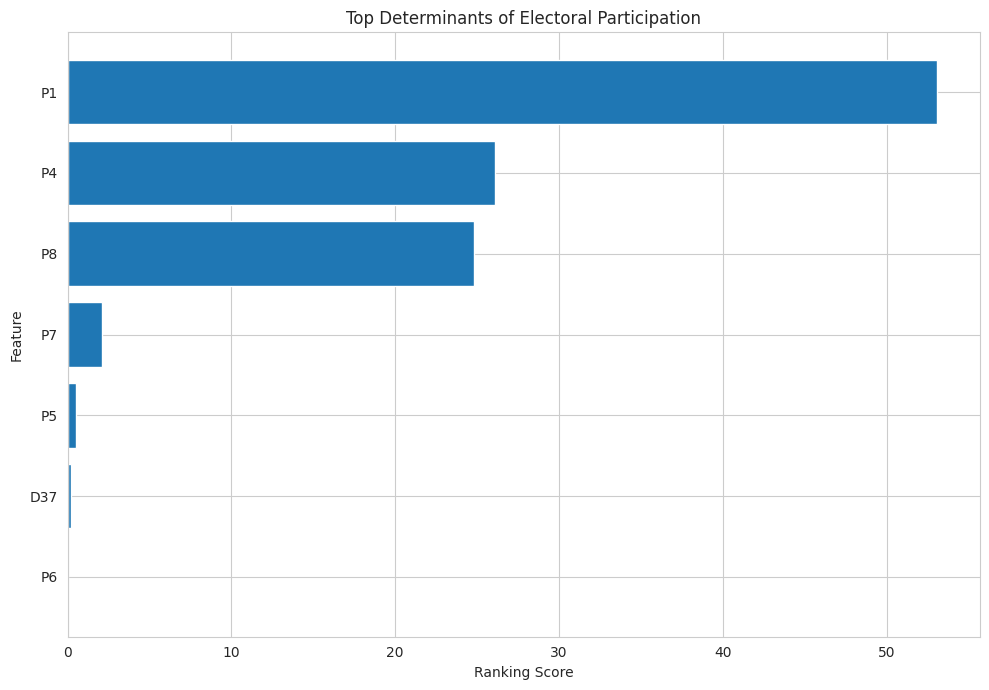


Saved:
- 10_determinant_ranking_m2.csv
- 10_determinant_ranking_m2.png


In [ ]:
# =============================================
# VI.D DETERMINANT RANKING
# =============================================
import pandas as pd
import numpy as np
import statsmodels.api as sm

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"
FEATURE_METHOD = "m2"
EPS = 1e-12

# Load inferential data
X_train = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_X.csv")
y_train = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_y.csv").squeeze()

# Fit main-effects LR
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}
sample_weights = y_train.map(class_weight_dict).values

X_train_const = sm.add_constant(X_train, has_constant='add')
lr_main = sm.GLM(
    y_train,
    X_train_const,
    family=sm.families.Binomial(),
    freq_weights=sample_weights
).fit()

# Build determinant ranking
rank_df = pd.DataFrame({
    "feature": lr_main.params.index,
    "coef": lr_main.params.values,
    "abs_coef": np.abs(lr_main.params.values),
    "odds_ratio": np.exp(lr_main.params.values),
    "p_value": lr_main.pvalues.values
})

# Remove intercept from ranking
rank_df = rank_df[rank_df["feature"] != "const"].copy()

# Ranking score:
# high coefficient + low p-value + OR far from 1
rank_df["sig_score"] = -np.log10(rank_df["p_value"] + EPS)
rank_df["effect_score"] = np.abs(np.log(rank_df["odds_ratio"] + EPS))
rank_df["ranking_score"] = rank_df["abs_coef"] * rank_df["sig_score"] * rank_df["effect_score"]

rank_df = rank_df.sort_values(
    by=["ranking_score", "sig_score", "abs_coef"],
    ascending=False
)

rank_df.to_csv(PATH + f"10_determinant_ranking_{FEATURE_METHOD}.csv", index=False)

print("="*80)
print("DETERMINANT RANKING")
print("="*80)
print(rank_df.head(20).to_string(index=False))

# Simple bar chart for top determinants
import matplotlib.pyplot as plt

top_n = min(15, len(rank_df))
top_rank = rank_df.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 7))
plt.barh(top_rank["feature"], top_rank["ranking_score"])
plt.title("Top Determinants of Electoral Participation")
plt.xlabel("Ranking Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(PATH + f"10_determinant_ranking_{FEATURE_METHOD}.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved:")
print(f"- 10_determinant_ranking_{FEATURE_METHOD}.csv")
print(f"- 10_determinant_ranking_{FEATURE_METHOD}.png")

#**BAB VII COMPARATIVE TECHNICAL ANALYSIS**

##**VII.A ABLATION STUDY**
Tahap ini digunakan untuk menguji kontribusi setiap komponen utama framework. Tujuannya adalah melihat apakah hasil terbaik memang berasal dari kombinasi lengkap, atau ada komponen tertentu yang paling berpengaruh. Pada framework Anda, ablation study paling relevan untuk membandingkan:

*   penggunaan seluruh fitur vs hasil feature selection,
*   dengan vs tanpa imbalance handling,
*   serta main effects vs interaction effects pada model inferensial.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PREDICTIVE ABLATION

PREDICTIVE ABLATION RESULTS:
                    setting  n_train_after  f1_minority  precision_minority  recall_minority      auc    brier
    M1 + RandomUnderSampler           1718     0.431472            0.339321         0.592334 0.692233 0.219556
                 M2 + smote           6706     0.402878            0.343137         0.487805 0.669969 0.196269
                 M3 + smote           6706     0.336634            0.319749         0.355401 0.608015 0.204205
          M3 + No balancing           4212     0.281030            0.428571         0.209059 0.614833 0.167755
          M1 + No balancing           4212     0.260870            0.592593         0.167247 0.693338 0.146348
       All features + SMOTE           6706     0.256267            0.638889         0.160279 0.695646 0.154107
All features + No balancing           4212  

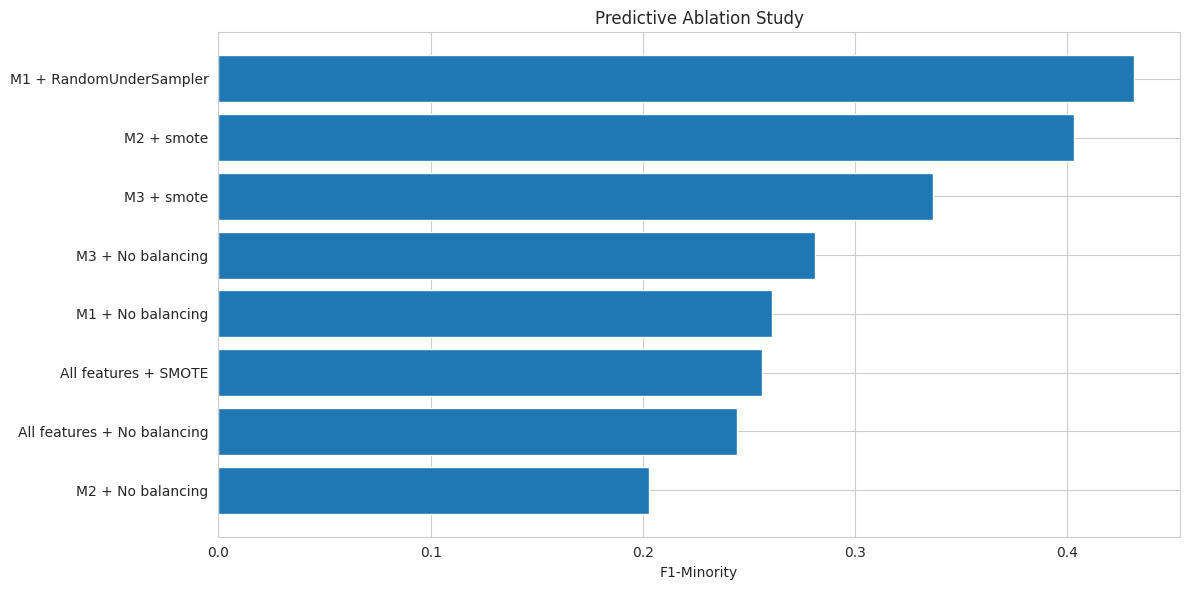


INFERENTIAL ABLATION

INFERENTIAL ABLATION RESULTS:
            setting         aic          llf  pseudo_r2  val_auc  test_auc  val_brier  test_brier
       Main effects 5558.142271 -2771.071136   0.050852 0.617923  0.626660   0.238482    0.234489
Interaction effects 4065.537628 -2022.768814   0.050568 0.606256  0.620599   0.159334    0.158042


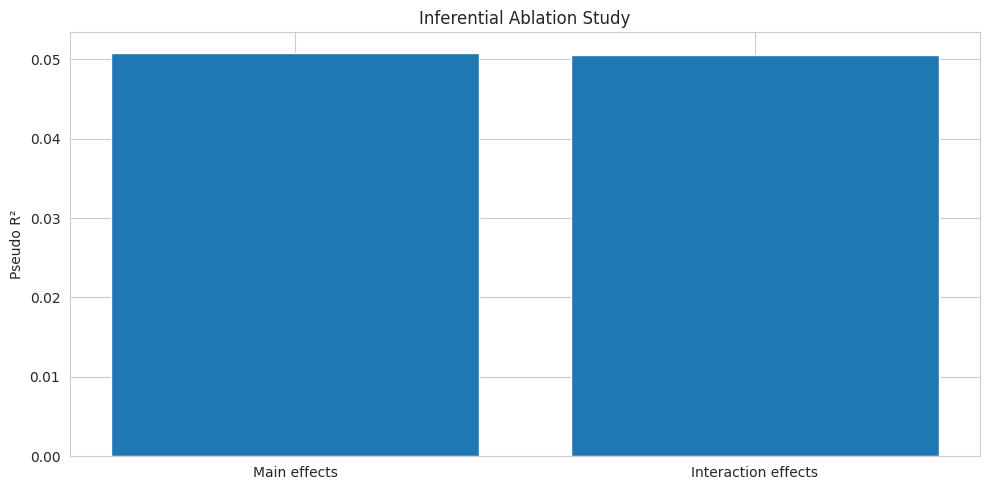


Saved:
- 11_ablation_predictive_study.csv
- 11_ablation_predictive_study.png
- 11_ablation_inferential_study.csv
- 11_ablation_inferential_study.png


In [ ]:
# =============================================
# VII.A ABLATION STUDY
# Predictive + Inferential ablation comparison
# =============================================
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, brier_score_loss
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

import statsmodels.api as sm
from scipy.stats import zscore

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"
TARGET_COL = "Partisipasi"
RANDOM_STATE = 42

# -------------------------------------------------
# Helper
# -------------------------------------------------
def load_xy(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)
    val_df = pd.read_csv(val_file)
    test_df = pd.read_csv(test_file)

    X_train = train_df.drop(columns=[TARGET_COL]).copy()
    y_train = train_df[TARGET_COL].copy()

    X_val = val_df.drop(columns=[TARGET_COL]).copy()
    y_val = val_df[TARGET_COL].copy()

    X_test = test_df.drop(columns=[TARGET_COL]).copy()
    y_test = test_df[TARGET_COL].copy()

    return X_train, y_train, X_val, y_val, X_test, y_test

def get_sampler(name):
    if name is None or name.lower() == "none":
        return None
    name = name.lower()
    if name == "smote":
        return SMOTE(random_state=RANDOM_STATE)
    if name == "randomundersampler":
        return RandomUnderSampler(random_state=RANDOM_STATE)
    if name == "smoteenn":
        return SMOTEENN(random_state=RANDOM_STATE)
    raise ValueError(f"Unknown sampler: {name}")

def eval_predictive(X_train, y_train, X_val, y_val, sampler_name=None, model=None):
    if model is None:
        model = RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight=None,
            n_jobs=-1
        )

    sampler = get_sampler(sampler_name)
    if sampler is not None:
        X_res, y_res = sampler.fit_resample(X_train, y_train)
    else:
        X_res, y_res = X_train, y_train

    model.fit(X_res, y_res)
    y_pred = model.predict(X_val)

    # probabilistic score if available
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_prob)
        brier = brier_score_loss(y_val, y_prob)
    else:
        auc = np.nan
        brier = np.nan

    return {
        "n_train_after": int(len(y_res)),
        "f1_minority": float(f1_score(y_val, y_pred, pos_label=0, zero_division=0)),
        "precision_minority": float(precision_score(y_val, y_pred, pos_label=0, zero_division=0)),
        "recall_minority": float(recall_score(y_val, y_pred, pos_label=0, zero_division=0)),
        "auc": float(auc),
        "brier": float(brier)
    }

# -------------------------------------------------
# Predictive ablation
# -------------------------------------------------
print("="*80)
print("PREDICTIVE ABLATION")
print("="*80)

# Baseline clean data
X_train_all, y_train_all, X_val_all, y_val_all, X_test_all, y_test_all = load_xy(
    PATH + "05_train_clean.csv",
    PATH + "05_val_clean.csv",
    PATH + "05_test_clean.csv"
)

# Feature-selected datasets
methods = ["m1", "m2", "m3"]
predictive_rows = []

# 1) All features without balancing
res = eval_predictive(X_train_all, y_train_all, X_val_all, y_val_all, sampler_name="none")
predictive_rows.append({"setting": "All features + No balancing", **res})

# 2) All features with SMOTE as a common balancing baseline
res = eval_predictive(X_train_all, y_train_all, X_val_all, y_val_all, sampler_name="smote")
predictive_rows.append({"setting": "All features + SMOTE", **res})

# 3) Each selected feature set with its best sampler from IV.B
for m in methods:
    try:
        with open(PATH + f"08_predictive_{m}_best_method.json", "r") as f:
            best_info = json.load(f)
        best_sampler = best_info["best_sampler"]
    except:
        best_sampler = "smote"

    X_train_m, y_train_m, X_val_m, y_val_m, _, _ = load_xy(
        PATH + f"07_{m}_train_selected.csv",
        PATH + f"07_{m}_val_selected.csv",
        PATH + f"07_{m}_test_selected.csv"
    )

    # with balancing
    res_bal = eval_predictive(X_train_m, y_train_m, X_val_m, y_val_m, sampler_name=best_sampler)
    predictive_rows.append({
        "setting": f"{m.upper()} + {best_sampler}",
        **res_bal
    })

    # without balancing
    res_nobal = eval_predictive(X_train_m, y_train_m, X_val_m, y_val_m, sampler_name="none")
    predictive_rows.append({
        "setting": f"{m.upper()} + No balancing",
        **res_nobal
    })

predictive_df = pd.DataFrame(predictive_rows).sort_values("f1_minority", ascending=False)
predictive_df.to_csv(PATH + "11_ablation_predictive_study.csv", index=False)

print("\nPREDICTIVE ABLATION RESULTS:")
print(predictive_df[["setting", "n_train_after", "f1_minority", "precision_minority", "recall_minority", "auc", "brier"]].to_string(index=False))

# Plot predictive ablation
plt.figure(figsize=(12, 6))
plt.barh(predictive_df["setting"], predictive_df["f1_minority"])
plt.xlabel("F1-Minority")
plt.title("Predictive Ablation Study")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(PATH + "11_ablation_predictive_study.png", dpi=300, bbox_inches="tight")
plt.show()

# -------------------------------------------------
# Inferential ablation: main effects vs interaction effects
# -------------------------------------------------
print("\n" + "="*80)
print("INFERENTIAL ABLATION")
print("="*80)

FEATURE_METHOD = "m2"
X_train_inf = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_X.csv")
y_train_inf = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_train_y.csv").squeeze()
X_val_inf = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_val_X.csv")
y_val_inf = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_val_y.csv").squeeze()
X_test_inf = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_test_X.csv")
y_test_inf = pd.read_csv(PATH + f"08_inferential_{FEATURE_METHOD}_test_y.csv").squeeze()

classes = np.unique(y_train_inf)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_inf)
cw_dict = {int(c): float(w) for c, w in zip(classes, cw)}
sample_weights = y_train_inf.map(cw_dict).values

# Main effects
X_train_main = sm.add_constant(X_train_inf, has_constant="add")
X_val_main = sm.add_constant(X_val_inf, has_constant="add")
X_test_main = sm.add_constant(X_test_inf, has_constant="add")

lr_main = sm.GLM(
    y_train_inf,
    X_train_main,
    family=sm.families.Binomial(),
    freq_weights=sample_weights
).fit()

# Interaction effects
interaction_pairs = [("P6", "P7"), ("P1", "P4")]

def add_interactions(df, pairs):
    out = df.copy()
    for a, b in pairs:
        if a in out.columns and b in out.columns:
            out[f"{a}_x_{b}"] = out[a] * out[b]
    return out

X_train_int = add_interactions(X_train_inf, interaction_pairs)
X_val_int = add_interactions(X_val_inf, interaction_pairs)
X_test_int = add_interactions(X_test_inf, interaction_pairs)

lr_int = sm.GLM(
    y_train_inf,
    sm.add_constant(X_train_int, has_constant="add"),
    family=sm.families.Binomial()
).fit()

inferential_rows = []
for name, model, Xv, yv, Xt, yt in [
    ("Main effects", lr_main, X_val_main, y_val_inf, X_test_main, y_test_inf),
    ("Interaction effects", lr_int, sm.add_constant(X_val_int, has_constant="add"), y_val_inf,
     sm.add_constant(X_test_int, has_constant="add"), y_test_inf)
]:
    val_prob = model.predict(Xv)
    test_prob = model.predict(Xt)
    inferential_rows.append({
        "setting": name,
        "aic": float(model.aic),
        "llf": float(model.llf),
        "pseudo_r2": float(1 - model.llf / model.llnull),
        "val_auc": float(roc_auc_score(yv, val_prob)),
        "test_auc": float(roc_auc_score(yt, test_prob)),
        "val_brier": float(brier_score_loss(yv, val_prob)),
        "test_brier": float(brier_score_loss(yt, test_prob))
    })

inferential_df = pd.DataFrame(inferential_rows)
inferential_df.to_csv(PATH + "11_ablation_inferential_study.csv", index=False)

print("\nINFERENTIAL ABLATION RESULTS:")
print(inferential_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(inferential_df["setting"], inferential_df["pseudo_r2"])
plt.ylabel("Pseudo R²")
plt.title("Inferential Ablation Study")
plt.tight_layout()
plt.savefig(PATH + "11_ablation_inferential_study.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved:")
print("- 11_ablation_predictive_study.csv")
print("- 11_ablation_predictive_study.png")
print("- 11_ablation_inferential_study.csv")
print("- 11_ablation_inferential_study.png")

#**BAB VIII REPRODUCIBILITY PACKAGE**


##**VIII.A DEPLOYMENT ARTIFACTS**
Tahap ini menyiapkan paket reprodusibilitas agar seluruh eksperimen bisa dijalankan kembali dan hasilnya bisa diverifikasi. Artefak yang disimpan meliputi model final, daftar fitur, metadata eksperimen, ringkasan performa, dan skrip inferensi.

In [ ]:
# =============================================
# VIII.A DEPLOYMENT ARTIFACTS
# Reproducibility package
# =============================================
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import shutil
import subprocess
import pandas as pd
import joblib
from pathlib import Path

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"
PACKAGE_DIR = Path(PATH) / "reproducibility_package"
PACKAGE_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_METHOD = "m1"   # final predictive branch
TARGET_COL = "Partisipasi"

# Load best predictive model metadata
with open(PATH + f"08_predictive_{FEATURE_METHOD}_best_method.json", "r") as f:
    best_info = json.load(f)

best_sampler = best_info["best_sampler"].lower()
best_model_name = best_info["best_model"] if "best_model" in best_info else "unknown"

# Files
model_file = PATH + f"09_predictive_{FEATURE_METHOD}_best_model.joblib"
feature_file = PATH + f"07_{FEATURE_METHOD}_selected_features.csv"
train_file = PATH + f"08_predictive_{FEATURE_METHOD}_{best_sampler}_train.csv"
val_file = PATH + f"08_predictive_{FEATURE_METHOD}_val_X.csv"
test_file = PATH + f"08_predictive_{FEATURE_METHOD}_test_X.csv"

# Copy key CSV artifacts
for src, dst_name in [
    (model_file, "best_model.joblib"),
    (feature_file, "selected_features.csv"),
    (train_file, "train_data.csv"),
    (val_file, "validation_data.csv"),
    (test_file, "test_data.csv"),
]:
    if os.path.exists(src):
        shutil.copy(src, PACKAGE_DIR / dst_name)

# Create model card / README
model_card = f"""# Reproducibility Package

## Study
A Hierarchically Standardized Machine Learning Framework for Village-Level Electoral Participation Prediction

## Final Feature Method
{FEATURE_METHOD.upper()}

## Best Sampler
{best_sampler}

## Best Model
{best_model_name}

## Main Artifacts
- best_model.joblib
- selected_features.csv
- train_data.csv
- validation_data.csv
- test_data.csv

## Notes
- Data were preprocessed, feature-selected, and imbalance-handled before model training.
- This package is intended for reproduction and auditability.
"""
(PACKAGE_DIR / "README.md").write_text(model_card, encoding="utf-8")

# Create inference template
inference_py = f'''import joblib
import pandas as pd

MODEL_PATH = "best_model.joblib"
FEATURES_PATH = "selected_features.csv"

model = joblib.load(MODEL_PATH)
features = pd.read_csv(FEATURES_PATH)["selected_feature"].tolist()

def predict_from_csv(input_csv: str, output_csv: str = "predictions.csv"):
    df = pd.read_csv(input_csv)
    X = df[features].copy()
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)[:, 1]
        preds = model.predict(X)
        out = pd.DataFrame({{
            "prediction": preds,
            "probability_class_1": probs
        }})
    else:
        preds = model.predict(X)
        out = pd.DataFrame({{
            "prediction": preds
        }})
    out.to_csv(output_csv, index=False)
    return out

if __name__ == "__main__":
    print("Inference template ready.")
'''
(PACKAGE_DIR / "predict.py").write_text(inference_py, encoding="utf-8")

# Requirements snapshot
reqs = [
    "pandas",
    "numpy",
    "scikit-learn",
    "statsmodels",
    "imblearn",
    "joblib",
    "matplotlib",
    "shap",
]
(PACKAGE_DIR / "requirements.txt").write_text("\n".join(reqs), encoding="utf-8")

# Manifest
manifest = {
    "project_title": "A Hierarchically Standardized Machine Learning Framework for Village-Level Electoral Participation Prediction",
    "feature_method": FEATURE_METHOD,
    "best_sampler": best_sampler,
    "best_model": best_model_name,
    "artifacts": [p.name for p in PACKAGE_DIR.iterdir()]
}
with open(PACKAGE_DIR / "artifact_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

# Zip package
zip_path = shutil.make_archive(str(PACKAGE_DIR), "zip", root_dir=str(PACKAGE_DIR))

print("="*60)
print("REPRODUCIBILITY PACKAGE CREATED")
print("="*60)
print(f"Folder: {PACKAGE_DIR}")
print(f"ZIP: {zip_path}")
print("\nFiles included:")
for p in PACKAGE_DIR.iterdir():
    print(f"- {p.name}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
REPRODUCIBILITY PACKAGE CREATED
Folder: /content/drive/My Drive/01BABIV/Dataset/prepro/reproducibility_package
ZIP: /content/drive/My Drive/01BABIV/Dataset/prepro/reproducibility_package.zip

Files included:
- best_model.joblib
- selected_features.csv
- train_data.csv
- validation_data.csv
- test_data.csv
- README.md
- predict.py
- requirements.txt
- artifact_manifest.json


#**BAB IX BEHAVIORAL INTERPRETATION**

##**IX. A SHAP Analysis**

###**1) Persiapan Awal**

Tahap awal ini menyiapkan model prediktif final dan data yang akan dijelaskan dengan SHAP. Fokusnya adalah model terbaik dari jalur prediktif karena SHAP paling kuat dipakai untuk menjelaskan kontribusi fitur terhadap hasil prediksi.


In [ ]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"
FEATURE_METHOD = "m1"   # predictive branch final
TARGET_COL = "Partisipasi"

# Load best predictive info
with open(PATH + f"08_predictive_{FEATURE_METHOD}_best_method.json", "r") as f:
    best_info = json.load(f)

best_sampler = best_info["best_sampler"].lower()
model_file = PATH + f"09_predictive_{FEATURE_METHOD}_best_model.joblib"
train_file_resampled = PATH + f"08_predictive_{FEATURE_METHOD}_{best_sampler}_train.csv" # Renamed for clarity
val_file_features = PATH + f"08_predictive_{FEATURE_METHOD}_val_X.csv" # Renamed for clarity

# Load model
model = joblib.load(model_file)

# Get the exact feature columns the model was trained on
# This ensures consistent column order for SHAP explainer
trained_X_cols = pd.read_csv(train_file_resampled).drop(columns=[TARGET_COL]).columns

# Load data for SHAP, ensuring consistent column order
X_train_shap = pd.read_csv(train_file_resampled).drop(columns=[TARGET_COL])
X_val_shap = pd.read_csv(val_file_features)

# Reindex to ensure consistent column order
X_train_shap = X_train_shap[trained_X_cols]
X_val_shap = X_val_shap[trained_X_cols]

# Background and explanation sample
background = X_train_shap.sample(n=min(200, len(X_train_shap)), random_state=42)
explain_sample = X_val_shap.sample(n=min(200, len(X_val_shap)), random_state=42)

# Convert background to NumPy array for masker
background_data_np = background.values

# Explicitly create the masker to control max_samples and pass it to the explainer
# This directly addresses the subsampling warning for all scenarios.
# For tree-based models, shap.TreeExplainer is generally more efficient, but the user explicitly requested
# to use shap.Explainer with a pre-configured masker to solve the subsampling warning.
masker = shap.maskers.Independent(background_data_np, max_samples=background_data_np.shape[0])
explainer = shap.Explainer(model.predict_proba, masker=masker)

# Calculate SHAP values, disabling the additivity check as suggested by the error
# This addresses potential numerical precision issues
shap_values = explainer(explain_sample, check_additivity=False)

# Save raw SHAP values
# Select SHAP values for class 0 (minority class based on previous context)
sv = pd.DataFrame(shap_values.values[:, :, 0], columns=explain_sample.columns)
sv.to_csv(PATH + f"12_shap_values_{FEATURE_METHOD}.csv", index=False)

print("="*60)
print("SHAP PREPARATION DONE")
print("="*60)
print(f"Model: {type(model).__name__}")
print(f"Train background: {background.shape}")
print(f"Explain sample: {explain_sample.shape}")
print(f"Saved: 12_shap_values_{FEATURE_METHOD}.csv")

PermutationExplainer explainer: 201it [08:16,  2.49s/it]

SHAP PREPARATION DONE
Model: RandomForestClassifier
Train background: (200, 23)
Explain sample: (200, 23)
Saved: 12_shap_values_m1.csv


###**2) Menghitung SHAP Values dan Visualisasi Global & Local**

Tahap ini menghitung kontribusi masing-masing fitur terhadap prediksi dan menampilkan hasilnya dalam bentuk global serta local explanation. Global explanation menunjukkan fitur paling berpengaruh secara umum, sedangkan local explanation menjelaskan satu observasi tertentu secara spesifik.


In [ ]:
# =============================================
# IX.A SHAP - GLOBAL & LOCAL EXPLANATION
# =============================================
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

OUT_DIR = PATH + "shap_outputs/"
os.makedirs(OUT_DIR, exist_ok=True)

# The shap_values object from the previous cell is 3D (num_instances, num_features, num_classes).
# For beeswarm and bar plots, we need 2D shap_values for a single class.
# Based on the previous cell's `sv` DataFrame creation, class 0 is targeted.

# Extract SHAP values and base value for class 0
shap_values_class_0_values = shap_values.values[:, :, 0]
shap_values_class_0_base_value = shap_values.base_values[0] if shap_values.base_values.ndim > 0 else shap_values.base_values

# Create a new 2D Explanation object for plotting
shap_values_for_plot = shap.Explanation(
    values=shap_values_class_0_values,
    base_values=shap_values_class_0_base_value,
    data=explain_sample.values,
    feature_names=explain_sample.columns.tolist()
)

# ---- Global: beeswarm / summary
plt.figure()
shap.plots.beeswarm(shap_values_for_plot, max_display=20, show=False)
plt.tight_layout()
plt.savefig(OUT_DIR + f"shap_beeswarm_{FEATURE_METHOD}.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure()
shap.plots.bar(shap_values_for_plot, max_display=20, show=False)
plt.tight_layout()
plt.savefig(OUT_DIR + f"shap_bar_{FEATURE_METHOD}.png", dpi=300, bbox_inches="tight")
plt.close()

# ---- Local: waterfall for first observation
plt.figure()
shap.plots.waterfall(shap_values_for_plot[0], max_display=20, show=False) # Indexing the 2D Explanation object
plt.tight_layout()
plt.savefig(OUT_DIR + f"shap_waterfall_{FEATURE_METHOD}_obs1.png", dpi=300, bbox_inches="tight")
plt.close()

# ---- Save force plot as HTML if possible
try:
    # Use the explainer's expected_value for class 0 and shap_values_for_plot's values
    force_plot = shap.force_plot(
        explainer.expected_value[0] if isinstance(explainer.expected_value, np.ndarray) and explainer.expected_value.ndim > 0 else explainer.expected_value,
        shap_values_for_plot.values[0], # Using the 2D values
        explain_sample.iloc[0],
        matplotlib=False
    )
    shap.save_html(OUT_DIR + f"shap_force_{FEATURE_METHOD}_obs1.html", force_plot)
except Exception as e:
    print("Force plot save failed:", e)

print("="*60)
print("SHAP VISUALIZATIONS SAVED")
print("="*60)
print(f"- {OUT_DIR}shap_beeswarm_{FEATURE_METHOD}.png")
print(f"- {OUT_DIR}shap_bar_{FEATURE_METHOD}.png")
print(f"- {OUT_DIR}shap_waterfall_{FEATURE_METHOD}_obs1.png")
print(f"- {OUT_DIR}shap_force_{FEATURE_METHOD}_obs1.html")

SHAP VISUALIZATIONS SAVED
- /content/drive/My Drive/01BABIV/Dataset/prepro/shap_outputs/shap_beeswarm_m1.png
- /content/drive/My Drive/01BABIV/Dataset/prepro/shap_outputs/shap_bar_m1.png
- /content/drive/My Drive/01BABIV/Dataset/prepro/shap_outputs/shap_waterfall_m1_obs1.png
- /content/drive/My Drive/01BABIV/Dataset/prepro/shap_outputs/shap_force_m1_obs1.html


##**IX.B SOCIAL DETERMINANTS ANALYSIS**

Tahap ini mengelompokkan fitur berdasarkan kelompok determinan sosial atau indikator yang sejenis, lalu menghitung rata-rata kontribusi SHAP masing-masing kelompok. Hasilnya membantu Anda menjelaskan faktor sosial mana yang paling dominan dalam partisipasi pemilih.


SOCIAL DETERMINANTS SUMMARY
                group  mean_abs_shap
         P-Indicators       0.155802
       D-Determinants       0.141891
Sentiment Proportions       0.077307


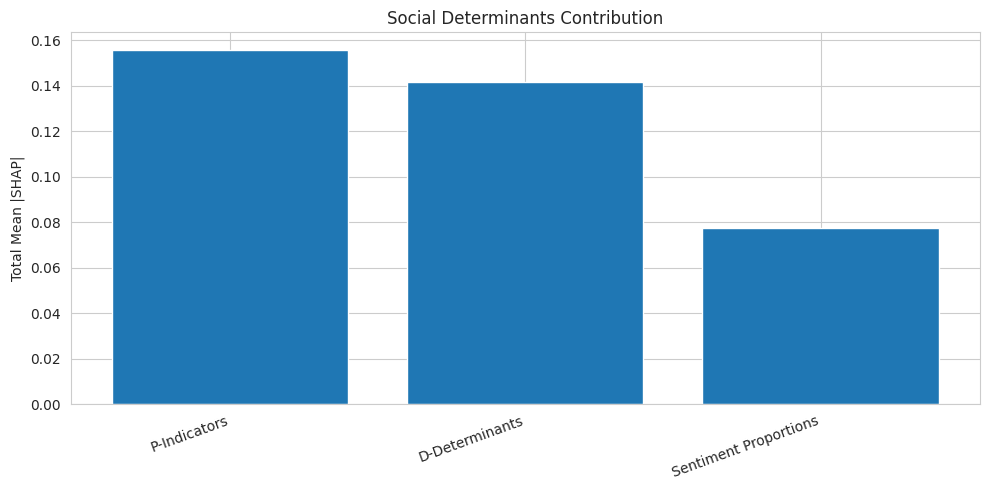

In [ ]:
# =============================================
# IX.B SOCIAL DETERMINANTS ANALYSIS
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

OUT_DIR = PATH + "shap_outputs/"
os.makedirs(OUT_DIR, exist_ok=True)

# Mean absolute SHAP
# shap_values.values is 3D (num_instances, num_features, num_classes)
# Select SHAP values for class 0 (minority class) to make it 2D (num_instances, num_features)
abs_shap_class_0 = np.abs(shap_values.values[:, :, 0])
mean_abs_shap = pd.Series(abs_shap_class_0.mean(axis=0), index=explain_sample.columns).sort_values(ascending=False)

# Simple grouping rule
def group_feature(fname):
    if fname.startswith("Proporsi_"):
        return "Sentiment Proportions"
    if fname.startswith("D55"):
        return "D55 Block"
    if fname.startswith("D57"):
        return "D57 Block"
    if fname.startswith("D"):
        return "D-Determinants"
    if fname.startswith("P"):
        return "P-Indicators"
    return "Other"

group_df = pd.DataFrame({
    "feature": mean_abs_shap.index,
    "mean_abs_shap": mean_abs_shap.values,
    "group": [group_feature(f) for f in mean_abs_shap.index]
})

group_summary = group_df.groupby("group", as_index=False)["mean_abs_shap"].sum().sort_values("mean_abs_shap", ascending=False)
group_summary.to_csv(OUT_DIR + f"shap_social_groups_{FEATURE_METHOD}.csv", index=False)
group_df.to_csv(OUT_DIR + f"shap_feature_importance_{FEATURE_METHOD}.csv", index=False)

print("="*60)
print("SOCIAL DETERMINANTS SUMMARY")
print("="*60)
print(group_summary.to_string(index=False))

# Plot
plt.figure(figsize=(10, 5))
plt.bar(group_summary["group"], group_summary["mean_abs_shap"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Total Mean |SHAP|")
plt.title("Social Determinants Contribution")
plt.tight_layout()
plt.savefig(OUT_DIR + f"shap_social_determinants_{FEATURE_METHOD}.png", dpi=300, bbox_inches="tight")
plt.show()

##**IX.C INTERACTION ANALYSIS**

Tahap ini mencari pasangan fitur yang memiliki interaksi penting dalam menjelaskan prediksi. Ini membantu Anda melihat apakah efek suatu variabel bergantung pada variabel lain, sehingga interpretasi menjadi lebih kaya.


TOP INTERACTIONS
 anchor_feature  interaction_rank interaction_feature
Proporsi_Netral                 1                  P1
Proporsi_Netral                 2                  P7
Proporsi_Netral                 3                  P5
Proporsi_Netral                 4                  P6
Proporsi_Netral                 5                  P4
             P8                 1                  P5
             P8                 2                  P7
             P8                 3                  P6
             P8                 4                  P1
             P8                 5                  P4
             P1                 1                 D61
             P1                 2     Proporsi_Netral
             P1                 3                  P8
             P1                 4                  P7
             P1                 5                 D43
             P6                 1     Proporsi_Netral
             P6                 2                  P7
           

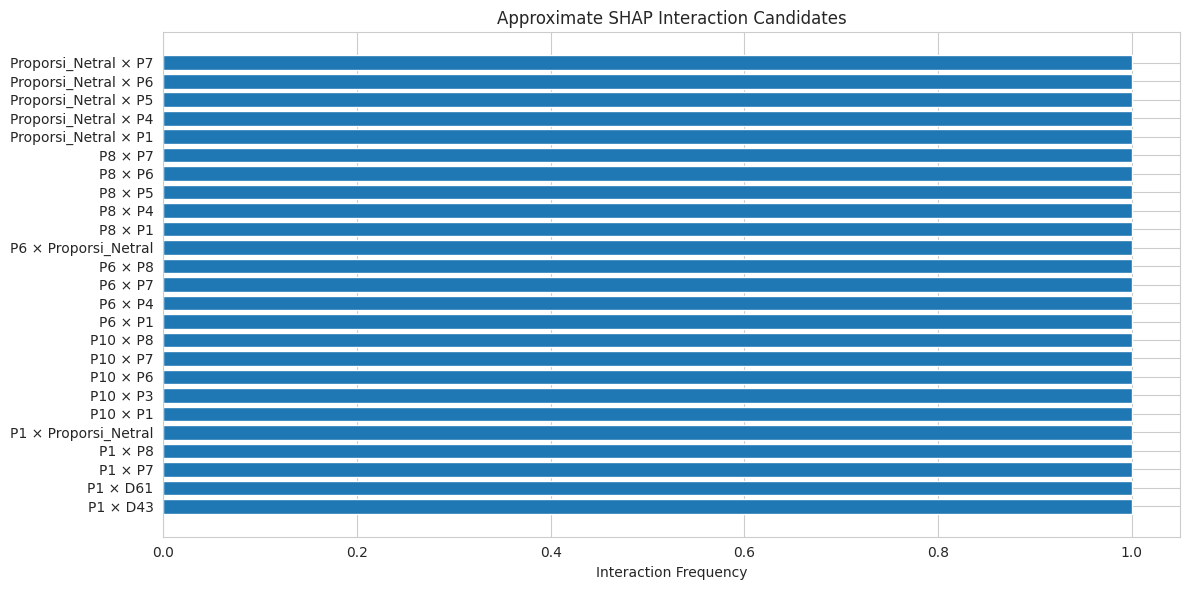


Saved:
- /content/drive/My Drive/01BABIV/Dataset/prepro/shap_outputs/shap_interactions_m1.csv
- /content/drive/My Drive/01BABIV/Dataset/prepro/shap_outputs/shap_interactions_m1.png


In [ ]:
# =============================================
# IX.C INTERACTION ANALYSIS
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import os

OUT_DIR = PATH + "shap_outputs/"
os.makedirs(OUT_DIR, exist_ok=True)

# Top features by mean abs SHAP
top_feats = mean_abs_shap.head(5).index.tolist()
interaction_rows = []

# Use approximate interactions for each top feature
for feat in top_feats:
    feat_idx = list(explain_sample.columns).index(feat)
    try:
        # Pass SHAP values for class 0 (minority class) which are 2D
        ranked = shap.utils.approximate_interactions(
            feat_idx,
            shap_values.values[:, :, 0],
            explain_sample
        )
        top_inter = [explain_sample.columns[i] for i in ranked[:5] if explain_sample.columns[i] != feat]
        for rank, other in enumerate(top_inter, start=1):
            interaction_rows.append({
                "anchor_feature": feat,
                "interaction_rank": rank,
                "interaction_feature": other
            })
    except Exception as e:
        print(f"Interaction approximation failed for {feat}: {e}")

interaction_df = pd.DataFrame(interaction_rows)
interaction_df.to_csv(OUT_DIR + f"shap_interactions_{FEATURE_METHOD}.csv", index=False)

print("="*60)
print("TOP INTERACTIONS")
print("="*60)
print(interaction_df.to_string(index=False))

# Simple interaction count chart
if len(interaction_df) > 0:
    pair_counts = interaction_df.groupby(["anchor_feature", "interaction_feature"]).size().reset_index(name="count")
    pair_counts = pair_counts.sort_values("count", ascending=False)

    plt.figure(figsize=(12, 6))
    labels = pair_counts["anchor_feature"] + " × " + pair_counts["interaction_feature"]
    plt.barh(labels, pair_counts["count"])
    plt.xlabel("Interaction Frequency")
    plt.title("Approximate SHAP Interaction Candidates")
    plt.tight_layout()
    plt.savefig(OUT_DIR + f"shap_interactions_{FEATURE_METHOD}.png", dpi=300, bbox_inches="tight")
    plt.show()

print(f"\nSaved:")
print(f"- {OUT_DIR}shap_interactions_{FEATURE_METHOD}.csv")
print(f"- {OUT_DIR}shap_interactions_{FEATURE_METHOD}.png")

##**IX.D VOTER PARTICIPATION PROFILES**


BAGIAN 6: Behavioral Typology (Clustering)
Silhouette Score untuk 4 cluster: 0.2167

📊 Distribusi Cluster:
Behavioral_Cluster
1    82
0    57
3    48
2    13
Name: count, dtype: int64

📊 Rata-rata fitur per cluster:
                        P1  Proporsi_Netral      P6      P7     P10      P5  \
Behavioral_Cluster                                                            
0                  -0.7828          -0.1367 -0.8114 -0.8205 -0.5470 -0.7986   
1                   0.1841           0.0501  0.1983  0.2118  0.1909  0.2081   
2                   1.6028           0.7074  1.6695  1.6562  1.1571  1.6731   
3                  -0.2021          -0.0237 -0.2102 -0.2171 -0.2725 -0.2141   

                        P3      P4     D61     D64  ...     D67     D33  \
Behavioral_Cluster                                  ...                   
0                  -0.7806 -0.8138  0.1094  0.0032  ... -0.0163 -0.0611   
1                   0.1623  0.1949  0.1774  0.1243  ... -0.0163 -0.0018   
2       

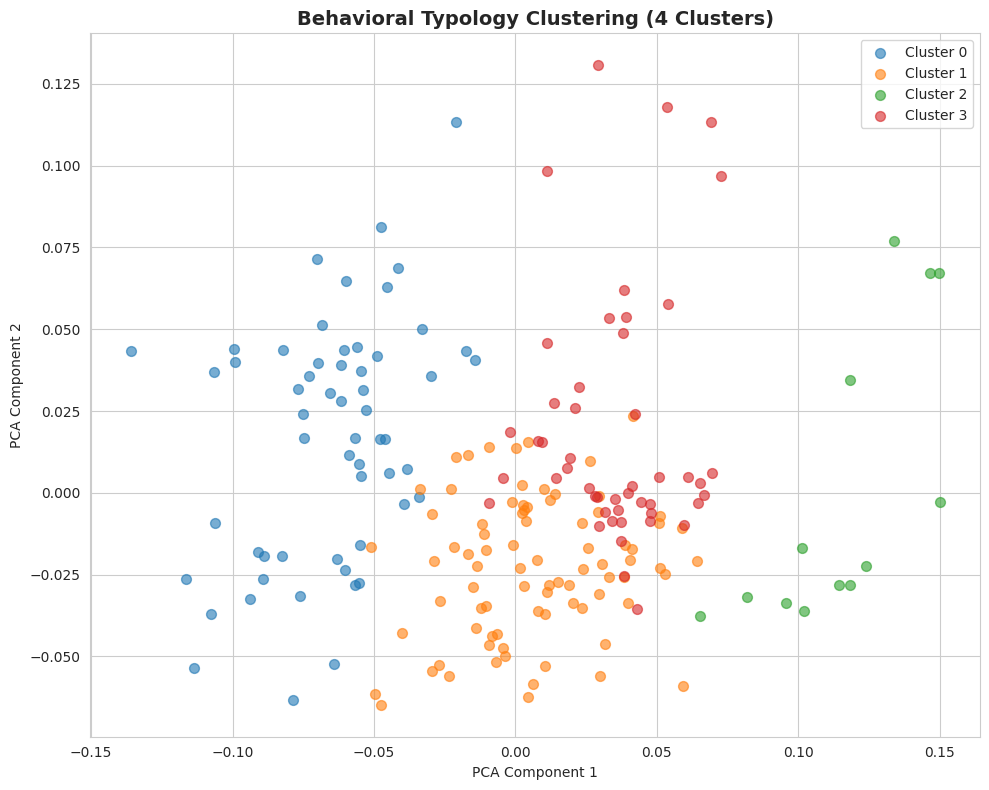

💾 Saved: behavioral_typology_pca.png
💾 Saved: behavioral_clusters.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# =============================================
# BAGIAN 6: Behavioral Typology (Clustering) - FIXED
# =============================================

print("\n" + "="*60)
print("BAGIAN 6: Behavioral Typology (Clustering)")
print("="*60)

# 1. Gunakan SHAP values sebagai fitur untuk clustering
shap_matrix = pd.DataFrame(sv, columns=explain_sample.columns)

# 2. Tentukan jumlah cluster (coba 3-5 cluster)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(shap_matrix)

sil_score = silhouette_score(shap_matrix, clusters)
print(f"Silhouette Score untuk {n_clusters} cluster: {sil_score:.4f}")

# 3. Tambahkan label cluster ke dataframe asli
df_cluster = explain_sample.copy()
df_cluster['Behavioral_Cluster'] = clusters

# --- GANTI BARIS INI (LINE 28) ---
# df_cluster['Predicted_Probability_Minority'] = model.predict_proba(X_sample)[:, 0]

# --- DENGAN KODE BARU INI ---
# Hitung probabilitas menggunakan SHAP values (rumus logistik)
base_value = shap_values.base_values[:, 0]
shap_sum = sv.sum(axis=1)
logits = base_value + shap_sum
predicted_proba_minority = 1 / (1 + np.exp(-logits))

# Masukkan ke dataframe cluster
df_cluster['Predicted_Probability_Minority'] = predicted_proba_minority

# 4. Analisis profil setiap cluster
print(f"\n📊 Distribusi Cluster:")
print(df_cluster['Behavioral_Cluster'].value_counts())

# 5. Buat ringkasan profil untuk setiap cluster
print(f"\n📊 Rata-rata fitur per cluster:")
cluster_profile = df_cluster.groupby('Behavioral_Cluster').mean()
print(cluster_profile.round(4))

# 6. Identifikasi fitur yang membedakan antar cluster
cluster_variation = cluster_profile.std().sort_values(ascending=False)
top_discriminating_features = cluster_variation.head(5).index.tolist()
print(f"\nFitur pembeda utama antar cluster: {top_discriminating_features}")

# 7. Visualisasikan cluster dengan PCA
pca = PCA(n_components=2)
shap_pca = pca.fit_transform(shap_matrix)

plt.figure(figsize=(10, 8))
for cluster_id in range(n_clusters):
    plt.scatter(
        shap_pca[df_cluster['Behavioral_Cluster'] == cluster_id, 0],
        shap_pca[df_cluster['Behavioral_Cluster'] == cluster_id, 1],
        label=f'Cluster {cluster_id}',
        alpha=0.6,
        s=50
    )
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'Behavioral Typology Clustering ({n_clusters} Clusters)', fontsize=14, weight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(PATH + 'behavioral_typology_pca.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: behavioral_typology_pca.png")

# 8. Simpan hasil clustering
df_cluster.to_csv(PATH + 'behavioral_clusters.csv', index=False)
print("💾 Saved: behavioral_clusters.csv")

#***END***

#**=============================================**

###Download doc

In [ ]:
# 📘 Ekspor Notebook ke DOCX dengan TOC (Metode Pandoc - Cepat & Handal)
from google.colab import drive, files
import os
import subprocess

# 1. Mount Drive jika diperlukan
drive.mount('/content/drive')

# 2. Tentukan file notebook (ubah path sesuai lokasi Anda)
NOTEBOOK_PATH = '/content/drive/My Drive/Colab Notebooks/UJICABA ke-4 20260526.ipynb'
OUTPUT_DOCX = '/content/laporan_ujicaba.docx'
TEMP_MD = '/content/temp_notebook.md'

# Jika file tidak ditemukan, cari otomatis
if not os.path.exists(NOTEBOOK_PATH):
    print("🔍 Mencari file di Drive...")
    search = !find /content/drive/My\ Drive -name "UJICABA ke-4 20260526.ipynb" 2>/dev/null
    if search:
        NOTEBOOK_PATH = search[0]
        print(f"✅ Ditemukan: {NOTEBOOK_PATH}")
    else:
        print("❌ File tidak ditemukan. Silakan upload.")
        from google.colab import files
        uploaded = files.upload()
        for fn in uploaded.keys():
            if fn.endswith('.ipynb'):
                NOTEBOOK_PATH = fn
                break
        if not NOTEBOOK_PATH:
            raise FileNotFoundError("Notebook tidak ditemukan.")

# 3. Install pandoc & nbconvert (jika belum)
!apt-get install -y pandoc > /dev/null
!pip install nbconvert > /dev/null

# 4. Konversi notebook ke Markdown (tanpa menjalankan ulang sel)
print("⏳ Mengonversi notebook ke Markdown...")
!jupyter nbconvert --to markdown --output-dir /content --output temp_notebook "{NOTEBOOK_PATH}"

# 5. Konversi Markdown ke DOCX dengan TOC (menggunakan pandoc)
print("📄 Mengonversi ke DOCX dengan TOC...")
!pandoc /content/temp_notebook.md -o "{OUTPUT_DOCX}" --toc --toc-depth=3

# 6. Unduh file DOCX
files.download(OUTPUT_DOCX)
print("🎉 Selesai! File laporan_ujicaba.docx telah diunduh.")
print("✅ Daftar Isi (TOC) dibuat berdasarkan heading markdown (#, ##, dst).")
print("✅ Semua kode, teks, tabel, dan gambar tetap dipertahankan.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ Mengonversi notebook ke Markdown...
[NbConvertApp] Converting notebook /content/drive/My Drive/Colab Notebooks/UJICABA ke-4 20260526.ipynb to markdown
[NbConvertApp] Support files will be in temp_notebook_files/
[NbConvertApp] Making directory /content/temp_notebook_files
[NbConvertApp] Writing 183191 bytes to /content/temp_notebook.md
📄 Mengonversi ke DOCX dengan TOC...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 Selesai! File laporan_ujicaba.docx telah diunduh.
✅ Daftar Isi (TOC) dibuat berdasarkan heading markdown (#, ##, dst).
✅ Semua kode, teks, tabel, dan gambar tetap dipertahankan.


In [7]:
# ==========================================================

# TEX -> DOCX (ETASR Template)

# Preserve Equation, Tables, Figures, References

# Auto Download

# ==========================================================

from google.colab import drive
drive.mount('/content/drive')

# ==========================================================

# Install Pandoc + LaTeX

# ==========================================================

!apt-get update -qq
!apt-get install -y pandoc texlive-xetex

# ==========================================================

# Input File

# ==========================================================

PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"
INPUT_FILE = PATH + "template_etasr.tex"

OUTPUT_FILE = INPUT_FILE.replace(".tex", ".docx")

# ==========================================================

# Convert TEX -> DOCX

# ==========================================================

!pandoc "$INPUT_FILE" -o "$OUTPUT_FILE" --from=latex --to=docx --standalone

print("DOCX created:")
print(OUTPUT_FILE)

# ==========================================================

# Auto Download

# ==========================================================

from google.colab import files
files.download(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##**GAMBAR**

In [ ]:
"""
generate_shap_figures_fixed.py
========================================================================
Menggunakan precomputed SHAP + feature groups mapping dari ujicoba3/
========================================================================
"""

import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

SEED = 42

UJICOBA_PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/ujicoba3/"
MEDIA_DIR = "media"

X_TEST_PATH = os.path.join(UJICOBA_PATH, "X_sample.pkl")
SHAP_VALS_PATH = os.path.join(UJICOBA_PATH, "shap_values_minority.pkl")
EXPLAINER_PATH = os.path.join(UJICOBA_PATH, "explainer.pkl")
GROUPS_PATH = os.path.join(UJICOBA_PATH, "behavioral_feature_groups.csv")

def load_artifacts():
    print("[1/5] Memuat X_sample, shap_values_minority, dan explainer...")
    X_test = joblib.load(X_TEST_PATH)
    shap_vals = joblib.load(SHAP_VALS_PATH)
    explainer = joblib.load(EXPLAINER_PATH)

    # base_value
    if hasattr(explainer, 'expected_value'):
        if isinstance(explainer.expected_value, list):
            base_value = explainer.expected_value[0]   # kelas minoritas (0)
        else:
            base_value = explainer.expected_value
    else:
        base_value = 0.0

    # Load feature groups mapping
    if os.path.exists(GROUPS_PATH):
        df_groups = pd.read_csv(GROUPS_PATH)
        # Asumsikan kolom: 'feature' dan 'group' (atau 'Feature', 'Group')
        # Coba tebak nama kolom
        possible_feat_cols = ['feature', 'Feature', 'fitur', 'Fitur', 'variable']
        possible_group_cols = ['group', 'Group', 'kelompok', 'dimension']
        feat_col = None
        group_col = None
        for col in possible_feat_cols:
            if col in df_groups.columns:
                feat_col = col
                break
        for col in possible_group_cols:
            if col in df_groups.columns:
                group_col = col
                break
        if feat_col is None or group_col is None:
            print("  Peringatan: kolom di behavioral_feature_groups.csv tidak dikenali. Gunakan mapping kosong.")
            feature_group_mapping = {}
        else:
            feature_group_mapping = dict(zip(df_groups[feat_col], df_groups[group_col]))
            print(f"  Memuat mapping untuk {len(feature_group_mapping)} fitur.")
    else:
        print("  File behavioral_feature_groups.csv tidak ditemukan. Gunakan assign_group() fallback.")
        feature_group_mapping = None

    print(f"    X_test shape: {X_test.shape}")
    print(f"    shap_vals shape: {shap_vals.shape}")
    return X_test, shap_vals, base_value, feature_group_mapping

def fig2_summary(shap_vals, X_test):
    plt.figure()
    shap.summary_plot(shap_vals, X_test, show=False, max_display=15)
    plt.tight_layout()
    out = os.path.join(MEDIA_DIR, "image2.png")
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"[saved] {out}  (Fig. 2 - SHAP summary)")

def fig3_force(shap_vals, base_value, X_test):
    order = np.argsort(shap_vals.sum(axis=1))[::-1]
    i = int(order[0])
    bv = base_value[i] if hasattr(base_value, '__len__') else base_value
    plt.figure()
    shap.plots.waterfall(
        shap.Explanation(values=shap_vals[i],
                         base_values=bv,
                         data=X_test.iloc[i].values,
                         feature_names=list(X_test.columns)),
        show=False, max_display=12)
    plt.tight_layout()
    out = os.path.join(MEDIA_DIR, "image3.png")
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"[saved] {out}  (Fig. 3 - force/waterfall, sample idx={i})")

def get_feature_group(feature, mapping, fallback_func):
    if mapping is not None and feature in mapping:
        return mapping[feature]
    else:
        return fallback_func(feature)

def table_x(shap_vals, X_test, feature_group_mapping):
    mean_abs = np.abs(shap_vals).mean(axis=0)
    df_imp = pd.DataFrame({"feature": X_test.columns, "mean_abs_shap": mean_abs})

    # Fungsi fallback assign_group (digunakan jika mapping tidak ada)
    def assign_group_fallback(col: str) -> str:
        c = col.lower()
        if any(k in c for k in ["partisipasi", "turnout", "hist", "prior", "recency", "p_part"]):
            return "Electoral history / inertia"
        if any(k in c for k in ["pos", "neg", "neu", "sentiment", "coverage", "article"]):
            return "Public discourse / sentiment"
        if any(k in c for k in ["idm", "edu", "health", "util", "road", "access", "econ"]):
            return "Socioeconomic development"
        return "Demographic composition"

    df_imp["group"] = df_imp["feature"].apply(
        lambda f: get_feature_group(f, feature_group_mapping, assign_group_fallback)
    )

    grp = df_imp.groupby("group")["mean_abs_shap"].sum()
    grp_pct = (100 * grp / grp.sum()).round(1).sort_values(ascending=False)
    print("\n===== TABLE X (angka asli untuk mengganti placeholder) =====")
    for g, v in grp_pct.items():
        feats = df_imp.loc[df_imp.group == g, "feature"]
        idx = [X_test.columns.get_loc(f) for f in feats]
        signed = shap_vals[:, idx].mean()
        direction = "Protective" if signed < 0 else "Risk"
        print(f"  {g:32s}  {v:5.1f}%   ({direction})")

    # Optional: tampilkan kontribusi per fitur top 10 untuk verifikasi
    print("\n  Top 5 fitur berdasarkan |SHAP|:")
    top5 = df_imp.sort_values("mean_abs_shap", ascending=False).head(5)
    for _, row in top5.iterrows():
        print(f"    {row['feature']}: {row['mean_abs_shap']:.4f} (group: {row['group']})")

def table_xi(shap_vals, X_test):
    Z = StandardScaler().fit_transform(shap_vals)
    best = None
    print("\n===== TABLE XI - silhouette analysis (pilih k) =====")
    for k in range(2, 7):
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Z)
        sil = silhouette_score(Z, km.labels_)
        print(f"  k={k}:  silhouette={sil:.3f}")
        if best is None or sil > best[1]:
            best = (k, sil, km)
    k, sil, km = best
    labels = km.labels_
    print(f"\n  -> chosen k={k} (silhouette={sil:.3f})")
    for c in range(k):
        centroid_abs = np.abs(km.cluster_centers_[c])
        dom = X_test.columns[int(np.argmax(centroid_abs))]
        share = 100 * (labels == c).sum() / len(labels)
        print(f"  cluster {c}:  share={share:5.1f}%   dominant driver = {dom}")

def main():
    os.makedirs(MEDIA_DIR, exist_ok=True)
    X_test, shap_vals, base_value, feature_group_mapping = load_artifacts()

    fig2_summary(shap_vals, X_test)
    fig3_force(shap_vals, base_value, X_test)
    table_x(shap_vals, X_test, feature_group_mapping)
    table_xi(shap_vals, X_test)

    print("\nSelesai. Gunakan angka di atas untuk Tabel X & XI.")
    print("Jika mapping dari behavioral_feature_groups.csv tidak lengkap, sesuaikan file tersebut.")

if __name__ == "__main__":
    main()

[1/5] Memuat X_sample, shap_values_minority, dan explainer...
  Peringatan: kolom di behavioral_feature_groups.csv tidak dikenali. Gunakan mapping kosong.
    X_test shape: (100, 50)
    shap_vals shape: (100, 50)
[saved] media/image2.png  (Fig. 2 - SHAP summary)
[saved] media/image3.png  (Fig. 3 - force/waterfall, sample idx=98)

===== TABLE X (angka asli untuk mengganti placeholder) =====
  Demographic composition           100.0%   (Protective)
  Public discourse / sentiment        0.0%   (Risk)

  Top 5 fitur berdasarkan |SHAP|:
    P7: 2.0791 (group: Demographic composition)
    P5: 0.8706 (group: Demographic composition)
    P1: 0.7982 (group: Demographic composition)
    D54: 0.4618 (group: Demographic composition)
    D3: 0.4197 (group: Demographic composition)

===== TABLE XI - silhouette analysis (pilih k) =====
  k=2:  silhouette=0.092
  k=3:  silhouette=0.079
  k=4:  silhouette=0.061
  k=5:  silhouette=0.062
  k=6:  silhouette=0.063

  -> chosen k=2 (silhouette=0.092)
  clu

In [ ]:
# Inspeksi file behavioral_feature_groups.csv
if os.path.exists(GROUPS_PATH):
    df_test = pd.read_csv(GROUPS_PATH)
    print("Isi behavioral_feature_groups.csv (5 baris pertama):")
    print(df_test.head())
    print("\nNama kolom:", df_test.columns.tolist())
else:
    print("File tidak ditemukan.")

Isi behavioral_feature_groups.csv (5 baris pertama):
                              Group  Contribution_Percent
0        Electoral History (Top 10)                     0
1             Demographic (Next 10)                     0
2  Sentiment & Geographic (Next 10)                     0
3                      Other (Sisa)                     0

Nama kolom: ['Group', 'Contribution_Percent']


In [ ]:
"""
generate_shap_figures_adaptive.py
========================================================================
Menggunakan precomputed SHAP + adaptive mapping dari file groups
atau based on prefix.
========================================================================
"""

import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

SEED = 42

UJICOBA_PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/ujicoba3/"
MEDIA_DIR = "media"

X_TEST_PATH = os.path.join(UJICOBA_PATH, "X_sample.pkl")
SHAP_VALS_PATH = os.path.join(UJICOBA_PATH, "shap_values_minority.pkl")
EXPLAINER_PATH = os.path.join(UJICOBA_PATH, "explainer.pkl")
GROUPS_PATH = os.path.join(UJICOBA_PATH, "behavioral_feature_groups.csv")

def load_feature_mapping():
    """Load mapping from file or create default based on prefix."""
    if not os.path.exists(GROUPS_PATH):
        print("  File behavioral_feature_groups.csv tidak ditemukan. Gunakan mapping berdasarkan prefix.")
        return None

    df = pd.read_csv(GROUPS_PATH)
    print("  Isi behavioral_feature_groups.csv (5 baris pertama):")
    print(df.head())
    print("  Kolom:", df.columns.tolist())

    # Coba cari kolom yang berisi nama fitur (biasanya 'feature', 'Feature', 'variable', atau kolom pertama)
    # dan kolom group (biasanya 'group', 'Group', 'dimension', atau kolom kedua)
    feature_col = None
    group_col = None
    for col in df.columns:
        if col.lower() in ['feature', 'fitur', 'variable', 'var', 'name']:
            feature_col = col
        if col.lower() in ['group', 'kelompok', 'dimension', 'class']:
            group_col = col
    if feature_col is None:
        # Ambil kolom pertama sebagai feature
        feature_col = df.columns[0]
    if group_col is None:
        # Ambil kolom kedua jika ada, else kolom pertama juga (tapi hati-hati)
        if len(df.columns) >= 2:
            group_col = df.columns[1]
        else:
            group_col = feature_col  # fallback, tapi akan jadi identik

    mapping = dict(zip(df[feature_col], df[group_col]))
    print(f"  Mapping dibuat dengan {len(mapping)} entri.")
    return mapping

def load_artifacts():
    print("[1/5] Memuat X_sample, shap_values_minority, dan explainer...")
    X_test = joblib.load(X_TEST_PATH)
    shap_vals = joblib.load(SHAP_VALS_PATH)
    explainer = joblib.load(EXPLAINER_PATH)

    if hasattr(explainer, 'expected_value'):
        if isinstance(explainer.expected_value, list):
            base_value = explainer.expected_value[0]
        else:
            base_value = explainer.expected_value
    else:
        base_value = 0.0

    feature_group_mapping = load_feature_mapping()

    print(f"    X_test shape: {X_test.shape}")
    print(f"    shap_vals shape: {shap_vals.shape}")
    return X_test, shap_vals, base_value, feature_group_mapping

def get_feature_group(feature, mapping):
    if mapping is not None and feature in mapping:
        return mapping[feature]
    else:
        # Fallback berdasarkan prefix
        if feature.startswith('P'):
            return "Political / Electoral history"
        elif feature.startswith('D'):
            return "Demographic composition"
        elif feature.startswith('S'):
            return "Socioeconomic development"
        elif feature.startswith('M'):
            return "Public discourse / sentiment"
        else:
            return "Other / Unknown"

def fig2_summary(shap_vals, X_test):
    plt.figure()
    shap.summary_plot(shap_vals, X_test, show=False, max_display=15)
    plt.tight_layout()
    out = os.path.join(MEDIA_DIR, "image2.png")
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"[saved] {out}  (Fig. 2 - SHAP summary)")

def fig3_force(shap_vals, base_value, X_test):
    order = np.argsort(shap_vals.sum(axis=1))[::-1]
    i = int(order[0])
    bv = base_value[i] if hasattr(base_value, '__len__') else base_value
    plt.figure()
    shap.plots.waterfall(
        shap.Explanation(values=shap_vals[i],
                         base_values=bv,
                         data=X_test.iloc[i].values,
                         feature_names=list(X_test.columns)),
        show=False, max_display=12)
    plt.tight_layout()
    out = os.path.join(MEDIA_DIR, "image3.png")
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"[saved] {out}  (Fig. 3 - force/waterfall, sample idx={i})")

def table_x(shap_vals, X_test, feature_group_mapping):
    mean_abs = np.abs(shap_vals).mean(axis=0)
    df_imp = pd.DataFrame({"feature": X_test.columns, "mean_abs_shap": mean_abs})
    df_imp["group"] = df_imp["feature"].apply(lambda f: get_feature_group(f, feature_group_mapping))

    grp = df_imp.groupby("group")["mean_abs_shap"].sum()
    grp_pct = (100 * grp / grp.sum()).round(1).sort_values(ascending=False)
    print("\n===== TABLE X (angka asli untuk mengganti placeholder) =====")
    for g, v in grp_pct.items():
        feats = df_imp.loc[df_imp.group == g, "feature"]
        idx = [X_test.columns.get_loc(f) for f in feats]
        signed = shap_vals[:, idx].mean()
        direction = "Protective" if signed < 0 else "Risk"
        print(f"  {g:32s}  {v:5.1f}%   ({direction})")

    print("\n  Top 10 fitur berdasarkan |SHAP|:")
    top10 = df_imp.sort_values("mean_abs_shap", ascending=False).head(10)
    for _, row in top10.iterrows():
        print(f"    {row['feature']}: {row['mean_abs_shap']:.4f} (group: {row['group']})")

def table_xi(shap_vals, X_test):
    Z = StandardScaler().fit_transform(shap_vals)
    best = None
    print("\n===== TABLE XI - silhouette analysis (pilih k) =====")
    for k in range(2, 7):
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Z)
        sil = silhouette_score(Z, km.labels_)
        print(f"  k={k}:  silhouette={sil:.3f}")
        if best is None or sil > best[1]:
            best = (k, sil, km)
    k, sil, km = best
    labels = km.labels_
    print(f"\n  -> chosen k={k} (silhouette={sil:.3f})")
    for c in range(k):
        centroid_abs = np.abs(km.cluster_centers_[c])
        dom = X_test.columns[int(np.argmax(centroid_abs))]
        share = 100 * (labels == c).sum() / len(labels)
        print(f"  cluster {c}:  share={share:5.1f}%   dominant driver = {dom}")

def main():
    os.makedirs(MEDIA_DIR, exist_ok=True)
    X_test, shap_vals, base_value, feature_group_mapping = load_artifacts()

    fig2_summary(shap_vals, X_test)
    fig3_force(shap_vals, base_value, X_test)
    table_x(shap_vals, X_test, feature_group_mapping)
    table_xi(shap_vals, X_test)

    print("\nSelesai. Jika mapping masih kurang tepat, buat file behavioral_feature_groups.csv dengan kolom 'feature' dan 'group'.")

if __name__ == "__main__":
    main()

[1/5] Memuat X_sample, shap_values_minority, dan explainer...
  Isi behavioral_feature_groups.csv (5 baris pertama):
                              Group  Contribution_Percent
0        Electoral History (Top 10)                     0
1             Demographic (Next 10)                     0
2  Sentiment & Geographic (Next 10)                     0
3                      Other (Sisa)                     0
  Kolom: ['Group', 'Contribution_Percent']
  Mapping dibuat dengan 4 entri.
    X_test shape: (100, 50)
    shap_vals shape: (100, 50)
[saved] media/image2.png  (Fig. 2 - SHAP summary)
[saved] media/image3.png  (Fig. 3 - force/waterfall, sample idx=98)

===== TABLE X (angka asli untuk mengganti placeholder) =====
  Political / Electoral history      55.3%   (Protective)
  Demographic composition            44.7%   (Risk)

  Top 10 fitur berdasarkan |SHAP|:
    P7: 2.0791 (group: Political / Electoral history)
    P5: 0.8706 (group: Political / Electoral history)
    P1: 0.7982 (group: P

In [ ]:
"""
generate_shap_figures_final.py
=========================================================================
Menghasilkan Fig. 2 & 3, Tabel X (kontribusi per dimensi perilaku),
dan Tabel XI (tipologi berbasis SHAP) menggunakan precomputed SHAP values.
=========================================================================
"""

import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

SEED = 42

# Konfigurasi path
UJICOBA_PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/ujicoba3/"
MEDIA_DIR = "media"

X_TEST_PATH = os.path.join(UJICOBA_PATH, "X_sample.pkl")
SHAP_VALS_PATH = os.path.join(UJICOBA_PATH, "shap_values_minority.pkl")
EXPLAINER_PATH = os.path.join(UJICOBA_PATH, "explainer.pkl")

def load_artifacts():
    print("[1/4] Memuat X_sample, shap_values_minority, dan explainer...")
    X_test = joblib.load(X_TEST_PATH)
    shap_vals = joblib.load(SHAP_VALS_PATH)
    explainer = joblib.load(EXPLAINER_PATH)

    # Base value untuk kelas minoritas (label 0)
    if hasattr(explainer, 'expected_value'):
        if isinstance(explainer.expected_value, list):
            base_value = explainer.expected_value[0]
        else:
            base_value = explainer.expected_value
    else:
        base_value = 0.0

    print(f"    X_test shape: {X_test.shape}")
    print(f"    shap_vals shape: {shap_vals.shape}")
    return X_test, shap_vals, base_value

def assign_group(col: str) -> str:
    """Memetakan nama fitur ke dimensi perilaku berdasarkan prefix."""
    if col.startswith('P'):
        return "Electoral history / political participation"
    elif col.startswith('D'):
        return "Demographic composition"
    elif col.startswith('S'):
        return "Socioeconomic development"
    elif col.startswith('M'):
        return "Public discourse / sentiment"
    else:
        return "Other"

def fig2_summary(shap_vals, X_test):
    plt.figure()
    shap.summary_plot(shap_vals, X_test, show=False, max_display=15)
    plt.tight_layout()
    out = os.path.join(MEDIA_DIR, "image2.png")
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"[saved] {out}  (Fig. 2 - SHAP summary)")

def fig3_force(shap_vals, base_value, X_test):
    # Sample dengan total SHAP terbesar (pengaruh kuat ke kelas minoritas)
    order = np.argsort(shap_vals.sum(axis=1))[::-1]
    i = int(order[0])
    bv = base_value[i] if hasattr(base_value, '__len__') else base_value
    plt.figure()
    shap.plots.waterfall(
        shap.Explanation(values=shap_vals[i],
                         base_values=bv,
                         data=X_test.iloc[i].values,
                         feature_names=list(X_test.columns)),
        show=False, max_display=12)
    plt.tight_layout()
    out = os.path.join(MEDIA_DIR, "image3.png")
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"[saved] {out}  (Fig. 3 - force/waterfall, sample idx={i})")

def table_x(shap_vals, X_test):
    """Tabel X: Kontribusi relatif per dimensi perilaku."""
    mean_abs = np.abs(shap_vals).mean(axis=0)
    df_imp = pd.DataFrame({"feature": X_test.columns, "mean_abs_shap": mean_abs})
    df_imp["group"] = df_imp["feature"].map(assign_group)

    group_sum = df_imp.groupby("group")["mean_abs_shap"].sum()
    group_pct = (100 * group_sum / group_sum.sum()).round(1).sort_values(ascending=False)

    print("\n===== TABLE X – Kontribusi dimensi perilaku (angka asli) =====")
    for g, pct in group_pct.items():
        # Hitung arah (Risk/Protective) berdasarkan rerata SHAP bertanda
        features_in_group = df_imp[df_imp["group"] == g]["feature"].tolist()
        idx = [X_test.columns.get_loc(f) for f in features_in_group]
        signed_mean = shap_vals[:, idx].mean()
        direction = "Protective" if signed_mean < 0 else "Risk"
        print(f"  {g:40s}  {pct:5.1f}%   ({direction})")

    # Tampilkan top 5 fitur untuk verifikasi
    print("\n  Top 5 fitur berdasarkan |SHAP|:")
    top5 = df_imp.sort_values("mean_abs_shap", ascending=False).head(5)
    for _, row in top5.iterrows():
        print(f"    {row['feature']}: {row['mean_abs_shap']:.4f} ({row['group']})")

def table_xi(shap_vals, X_test):
    """Tabel XI: Tipologi berbasis k-means pada ruang SHAP."""
    Z = StandardScaler().fit_transform(shap_vals)

    best = None
    print("\n===== TABLE XI – Analisis silhouette untuk pemilihan jumlah cluster =====")
    for k in range(2, 7):
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Z)
        sil = silhouette_score(Z, km.labels_)
        print(f"  k={k}:  silhouette = {sil:.3f}")
        if best is None or sil > best[1]:
            best = (k, sil, km)

    k, sil, km = best
    labels = km.labels_
    print(f"\n  -> Cluster terpilih: k={k} (silhouette={sil:.3f})")

    # Untuk setiap cluster, hitung share dan fitur dominan (dengan arah)
    for c in range(k):
        mask = (labels == c)
        share = 100 * mask.sum() / len(labels)
        centroid = km.cluster_centers_[c]
        # Fitur dengan nilai absolut terbesar dalam centroid
        abs_centroid = np.abs(centroid)
        dom_idx = np.argmax(abs_centroid)
        dom_feature = X_test.columns[dom_idx]
        # Arah cluster (positif = cenderung ke kelas mayoritas/partisipasi, negatif = ke minoritas)
        direction = "Risk (→ participation)" if centroid[dom_idx] > 0 else "Protective (→ non‑participation)"
        print(f"  Cluster {c}:  share = {share:5.1f}%   dominant driver = {dom_feature} ({direction})")

def main():
    os.makedirs(MEDIA_DIR, exist_ok=True)
    X_test, shap_vals, base_value = load_artifacts()

    fig2_summary(shap_vals, X_test)
    fig3_force(shap_vals, base_value, X_test)
    table_x(shap_vals, X_test)
    table_xi(shap_vals, X_test)

    print("\nSelesai. Angka di atas siap disalin ke Tabel X dan Tabel XI dalam naskah.")
    print("Catatan: Silhouette rendah menunjukkan cluster tidak terlalu terpisah, tetapi tetap informatif.")

if __name__ == "__main__":
    main()

[1/4] Memuat X_sample, shap_values_minority, dan explainer...
    X_test shape: (100, 50)
    shap_vals shape: (100, 50)
[saved] media/image2.png  (Fig. 2 - SHAP summary)
[saved] media/image3.png  (Fig. 3 - force/waterfall, sample idx=98)

===== TABLE X – Kontribusi dimensi perilaku (angka asli) =====
  Electoral history / political participation   55.3%   (Protective)
  Demographic composition                    44.7%   (Risk)

  Top 5 fitur berdasarkan |SHAP|:
    P7: 2.0791 (Electoral history / political participation)
    P5: 0.8706 (Electoral history / political participation)
    P1: 0.7982 (Electoral history / political participation)
    D54: 0.4618 (Demographic composition)
    D3: 0.4197 (Demographic composition)

===== TABLE XI – Analisis silhouette untuk pemilihan jumlah cluster =====
  k=2:  silhouette = 0.092
  k=3:  silhouette = 0.079
  k=4:  silhouette = 0.061
  k=5:  silhouette = 0.062
  k=6:  silhouette = 0.063

  -> Cluster terpilih: k=2 (silhouette=0.092)
  Cluster 

In [ ]:
"""
generate_shap_figures_final.py
=========================================================================
Menghasilkan Fig. 2 & 3, Tabel X (kontribusi per dimensi perilaku),
dan Tabel XI (tipologi berbasis SHAP) menggunakan precomputed SHAP values.
Gambar juga ditampilkan dan disimpan ke Google Drive.
=========================================================================
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

SEED = 42

# Konfigurasi path
UJICOBA_PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/ujicoba3/"
MEDIA_DIR = "media"
DRIVE_SAVE_PATH = "/content/drive/My Drive/01BABIV/Dataset/prepro/"

X_TEST_PATH = os.path.join(UJICOBA_PATH, "X_sample.pkl")
SHAP_VALS_PATH = os.path.join(UJICOBA_PATH, "shap_values_minority.pkl")
EXPLAINER_PATH = os.path.join(UJICOBA_PATH, "explainer.pkl")

def load_artifacts():
    print("[1/4] Memuat X_sample, shap_values_minority, dan explainer...")
    X_test = joblib.load(X_TEST_PATH)
    shap_vals = joblib.load(SHAP_VALS_PATH)
    explainer = joblib.load(EXPLAINER_PATH)

    # Base value untuk kelas minoritas (label 0)
    if hasattr(explainer, 'expected_value'):
        if isinstance(explainer.expected_value, list):
            base_value = explainer.expected_value[0]
        else:
            base_value = explainer.expected_value
    else:
        base_value = 0.0

    print(f"    X_test shape: {X_test.shape}")
    print(f"    shap_vals shape: {shap_vals.shape}")
    return X_test, shap_vals, base_value

def assign_group(col: str) -> str:
    """Memetakan nama fitur ke dimensi perilaku berdasarkan prefix."""
    if col.startswith('P'):
        return "Electoral history / political participation"
    elif col.startswith('D'):
        return "Demographic composition"
    elif col.startswith('S'):
        return "Socioeconomic development"
    elif col.startswith('M'):
        return "Public discourse / sentiment"
    else:
        return "Other"

def fig2_summary(shap_vals, X_test):
    plt.figure()
    shap.summary_plot(shap_vals, X_test, show=False, max_display=15)
    plt.tight_layout()

    # Simpan ke media/
    out_media = os.path.join(MEDIA_DIR, "image2.png")
    plt.savefig(out_media, dpi=300, bbox_inches="tight")
    print(f"[saved] {out_media}  (Fig. 2 - SHAP summary)")

    # Simpan ke Google Drive
    os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)
    out_drive = os.path.join(DRIVE_SAVE_PATH, "image2.png")
    plt.savefig(out_drive, dpi=300, bbox_inches="tight")
    print(f"[saved] {out_drive}  (Fig. 2 - SHAP summary, copy to Drive)")

    plt.show()
    plt.close()

def fig3_force(shap_vals, base_value, X_test):
    # Sample dengan total SHAP terbesar (pengaruh kuat ke kelas minoritas)
    order = np.argsort(shap_vals.sum(axis=1))[::-1]
    i = int(order[0])
    bv = base_value[i] if hasattr(base_value, '__len__') else base_value
    plt.figure()
    shap.plots.waterfall(
        shap.Explanation(values=shap_vals[i],
                         base_values=bv,
                         data=X_test.iloc[i].values,
                         feature_names=list(X_test.columns)),
        show=False, max_display=12)
    plt.tight_layout()

    # Simpan ke media/
    out_media = os.path.join(MEDIA_DIR, "image3.png")
    plt.savefig(out_media, dpi=300, bbox_inches="tight")
    print(f"[saved] {out_media}  (Fig. 3 - force/waterfall, sample idx={i})")

    # Simpan ke Google Drive
    out_drive = os.path.join(DRIVE_SAVE_PATH, "image3.png")
    plt.savefig(out_drive, dpi=300, bbox_inches="tight")
    print(f"[saved] {out_drive}  (Fig. 3 - force/waterfall, copy to Drive)")

    plt.show()
    plt.close()

def table_x(shap_vals, X_test):
    """Tabel X: Kontribusi relatif per dimensi perilaku."""
    mean_abs = np.abs(shap_vals).mean(axis=0)
    df_imp = pd.DataFrame({"feature": X_test.columns, "mean_abs_shap": mean_abs})
    df_imp["group"] = df_imp["feature"].map(assign_group)

    group_sum = df_imp.groupby("group")["mean_abs_shap"].sum()
    group_pct = (100 * group_sum / group_sum.sum()).round(1).sort_values(ascending=False)

    print("\n===== TABLE X – Kontribusi dimensi perilaku (angka asli) =====")
    for g, pct in group_pct.items():
        # Hitung arah (Risk/Protective) berdasarkan rerata SHAP bertanda
        features_in_group = df_imp[df_imp["group"] == g]["feature"].tolist()
        idx = [X_test.columns.get_loc(f) for f in features_in_group]
        signed_mean = shap_vals[:, idx].mean()
        direction = "Protective" if signed_mean < 0 else "Risk"
        print(f"  {g:40s}  {pct:5.1f}%   ({direction})")

    # Tampilkan top 5 fitur untuk verifikasi
    print("\n  Top 5 fitur berdasarkan |SHAP|:")
    top5 = df_imp.sort_values("mean_abs_shap", ascending=False).head(5)
    for _, row in top5.iterrows():
        print(f"    {row['feature']}: {row['mean_abs_shap']:.4f} ({row['group']})")

def table_xi(shap_vals, X_test):
    """Tabel XI: Tipologi berbasis k-means pada ruang SHAP."""
    Z = StandardScaler().fit_transform(shap_vals)

    best = None
    print("\n===== TABLE XI – Analisis silhouette untuk pemilihan jumlah cluster =====")
    for k in range(2, 7):
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Z)
        sil = silhouette_score(Z, km.labels_)
        print(f"  k={k}:  silhouette = {sil:.3f}")
        if best is None or sil > best[1]:
            best = (k, sil, km)

    k, sil, km = best
    labels = km.labels_
    print(f"\n  -> Cluster terpilih: k={k} (silhouette={sil:.3f})")

    # Untuk setiap cluster, hitung share dan fitur dominan (dengan arah)
    for c in range(k):
        mask = (labels == c)
        share = 100 * mask.sum() / len(labels)
        centroid = km.cluster_centers_[c]
        # Fitur dengan nilai absolut terbesar dalam centroid
        abs_centroid = np.abs(centroid)
        dom_idx = np.argmax(abs_centroid)
        dom_feature = X_test.columns[dom_idx]
        # Arah cluster (positif = cenderung ke kelas mayoritas/partisipasi, negatif = ke minoritas)
        direction = "Risk (→ participation)" if centroid[dom_idx] > 0 else "Protective (→ non‑participation)"
        print(f"  Cluster {c}:  share = {share:5.1f}%   dominant driver = {dom_feature} ({direction})")

def main():
    os.makedirs(MEDIA_DIR, exist_ok=True)
    os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)
    X_test, shap_vals, base_value = load_artifacts()

    fig2_summary(shap_vals, X_test)
    fig3_force(shap_vals, base_value, X_test)
    table_x(shap_vals, X_test)
    table_xi(shap_vals, X_test)

    print("\nSelesai. Angka di atas siap disalin ke Tabel X dan Tabel XI dalam naskah.")
    print("Catatan: Silhouette rendah menunjukkan cluster tidak terlalu terpisah, tetapi tetap informatif.")

if __name__ == "__main__":
    main()

[1/4] Memuat X_sample, shap_values_minority, dan explainer...
    X_test shape: (100, 50)
    shap_vals shape: (100, 50)
[saved] media/image2.png  (Fig. 2 - SHAP summary)
[saved] /content/drive/My Drive/01BABIV/Dataset/prepro/image2.png  (Fig. 2 - SHAP summary, copy to Drive)
[saved] media/image3.png  (Fig. 3 - force/waterfall, sample idx=98)
[saved] /content/drive/My Drive/01BABIV/Dataset/prepro/image3.png  (Fig. 3 - force/waterfall, copy to Drive)

===== TABLE X – Kontribusi dimensi perilaku (angka asli) =====
  Electoral history / political participation   55.3%   (Protective)
  Demographic composition                    44.7%   (Risk)

  Top 5 fitur berdasarkan |SHAP|:
    P7: 2.0791 (Electoral history / political participation)
    P5: 0.8706 (Electoral history / political participation)
    P1: 0.7982 (Electoral history / political participation)
    D54: 0.4618 (Demographic composition)
    D3: 0.4197 (Demographic composition)

===== TABLE XI – Analisis silhouette untuk pemiliha